# Component: West Antarctic Ice Sheet (WAIS)

This notebook implements the A4 deep-uncertainty framework for the WAIS
contribution to global mean sea level (GMSL). Unlike all other components
(thermosteric, glaciers, Greenland), WAIS **cannot be modeled with a
data-driven rate–temperature regression**: the observational record (28 years
of IMBIE satellite gravimetry) is too short to constrain a temperature-dependent
response for a system whose instabilities unfold over decades to centuries, and
the physics of marine ice sheet instability (MISI) involves threshold processes
poorly represented by smooth functional forms. We therefore adopt a
scenario-based approach.

---

## A4 Framework: Three-Scenario Mixture

The A4 framework constructs a probability distribution over WAIS contributions
at 2100 from a discrete mixture of physically distinct regimes. Each scenario
specifies a weight (prior probability), a 5th–95th percentile range for
cumulative SLR at 2100, a skewness parameter $\alpha$, and a trajectory
exponent $\beta$.

| Scenario | $P$ | Range (mm) | $\alpha$ | $\beta$ | Physical regime |
|----------|-----|------------|----------|---------|-----------------|
| **S1**: Status quo | 0.10 | 25–85 | 0 | 1.0 (fixed) | No MISI; linear melt-driven discharge |
| **S2**: MISI | 0.80 | 150–1000 | +4 | LN(1.8, 0.3) | Marine ice sheet instability |
| **S3**: MISI + MICI | 0.10 | 600–1300 | −3 | LN(2.2, 0.3) | Ice cliff instability added |

All scenario ranges and $\beta$ priors are defined at the reference rheology
$n_{\text{ref}} = 3$ (Glen's flow law exponent used by all ISMIP6 models and
the literature that informs our bounds). A rheology correction for the
observed $n \approx 4.1$ is applied to both the endpoint and the trajectory
— see **Rheology correction** below.

The combined A4 distribution is **SSP-independent**.

---

## Scenario Justification

### S1: Status quo ($P = 0.10$; 25–85 mm)

MISI does not operate — bed topography (ridges, pinning points), mélange
buttressing, and ice-shelf re-formation prevent the runaway grounding-line
flux feedback from activating, regardless of ocean warming. Discharge
responds linearly to ocean thermal forcing without instability amplification.

**Physical derivation of the range:**

The S1 bounds are derived from observed WAIS discharge sensitivity to ocean
thermal forcing, projected ocean warming, and the melt–discharge linearity
established by Joughin et al. (2021).

**Step 1 — Melt–discharge linearity (Joughin et al. 2021).** For Pine
Island Glacier, grounded ice loss scales linearly with time-averaged total
melt volume ($r^2 \geq 0.98$), with a coefficient of 0.34 mm SLE per Gt/yr
of 200-yr-averaged melt. This linearity holds across ASE sectors in the
ISMIP6 multi-model ensemble ($r^2 \geq 0.94$), validating a linear
melt→discharge scaling for aggregate WAIS discharge in the absence of MISI.

**Step 2 — Melt sensitivity to ocean thermal forcing.** Basal melt scales
quadratically with thermal forcing: $\dot{m} \propto (T_{\text{ocean}} -
T_f)^2$ (Joughin et al. 2021; standard plume parameterization). Current
conditions: PIG shelf melt ~67 Gt/yr at thermal forcing
$\Delta T_0 \approx 2.15°$C above in situ freezing.

**Step 3 — Projected ocean warming (Naughten et al. 2023).** Amundsen
shelf (200–700 m) warms by +0.7 to +1.5°C above present by 2100
(Paris 1.5°C through RCP 8.5). The three lower scenarios are statistically
indistinguishable; only RCP 8.5 separates.

**Step 4 — Melt enhancement factor.** Combining Steps 2 and 3:
$f = [(\Delta T_0 + \Delta T_{\text{warm}}) / \Delta T_0]^2$.
At +1.5°C (RCP 8.5 upper end): $f = [(2.15 + 1.5)/2.15]^2 \approx 2.9$.
At +0.7°C (Paris 1.5°C): $f = [(2.15 + 0.7)/2.15]^2 \approx 1.7$.
Consistent with Jourdain et al. (2022): 1.4–2.2× under RCP 8.5.

**Step 5 — Rate ramp.** From Step 1, discharge scales linearly with melt,
so the WAIS discharge rate scales by the same factor $f$.

- *Lower bound*: IMBIE 1992–2020 time-averaged rate ≈ 0.24 mm/yr
  (6.6 mm over 28 years). Sustained without further acceleration:
  $0.24 \times 95 \approx$ **23 mm**. Rounding to 25 mm.
- *Upper bound*: Peak IMBIE rate ~0.44 mm/yr (Otosaka et al. 2023) as
  starting rate, ramping with $f = 2.9$ (RCP 8.5, +1.5°C):
  $r_{2100} = 0.44 \times 2.9 \approx 1.3$ mm/yr. Linear ramp:
  $(0.44 + 1.3)/2 \times 95 \approx$ **83 mm**. Rounding to 85 mm.

The lower bound uses the time-averaged rate (which includes the post-2010
deceleration) as a sustained floor. The upper bound uses the peak rate as
the starting point (defensible because the deceleration may reflect decadal
CDW variability rather than a secular trend; Naughten et al. 2023 show
shelf warming re-accelerates under all scenarios) and applies the quadratic
melt scaling at the upper end of projected warming.

- **Low weight (10%)** reflects growing evidence that MISI may already be
  underway: grounding-line retreat on retrograde beds observed at Thwaites
  (Joughin et al. 2014); committed ocean thermal forcing sufficient for
  WAIS retreat regardless of emissions pathway (Naughten et al. 2023);
  present-day forcing sufficient to deglaciate large WAIS sectors
  (van den Akker et al. 2025).
- **$\alpha = 0$**: Symmetric (log-normal). No flux-geometry feedback
  operating to skew the distribution.
- **$\beta = 1.0$** (fixed): Constant rate — appropriate when MISI is not
  triggered and grounding lines remain stable.

### S2: MISI ($P = 0.80$; 150–1000 mm; $\alpha = +4$)

Marine ice sheet instability is triggered, with the full range of amplifying
processes that current models omit.

- **Lower bound (150 mm)**: The minimum physically consistent WAIS
  contribution if MISI operates. This is anchored to
  transient-calibrated ice sheet model projections (Goldberg et al.
  2026) and observed grounding-line retreat rates (Rignot et al.
  2026), building the total from individual basin contributions:

  *Thwaites* ($\sim$40 mm): Goldberg et al. (2026) calibrated two
  independent ice sheet models (STREAMICE, ISSM) against observed
  surface elevation changes — the constraint most directly relevant
  to mass loss. Their surface-constrained models produce $V_{af}$
  loss rates of 180–200 Gt/a by 2067 from the Thwaites trunk
  subdomain, with thinning extending $\sim$100 km inland along the
  deep trough. Integrating the trajectory to 2067 ($\sim$4750 Gt)
  and conservatively assuming the rate plateaus at the transverse
  ridge through 2100 ($190 \times 33 \approx 6270$ Gt), the trunk
  contributes $\sim$30 mm SLE. Scaling to the full Thwaites
  catchment (trunk $\approx$ 75% of dynamic loss) gives
  $\sim$40 mm SLE. This is from $n = 3$ with no calving and no
  subglacial hydrology — every omission biases low.

  *PIG* ($\sim$40 mm): Pine Island Glacier has retreated 33 km
  since 1992 (Rignot et al. 2026), shares the same ocean forcing
  and retrograde bed geometry as Thwaites, and has comparable
  present-day mass loss ($\sim$80–130 Gt/a). Under MISI, PIG
  follows a qualitatively similar trajectory to Thwaites.

  *Smith/Kohler* ($\sim$12 mm): 43 km GL retreat since 1996
  (Rignot et al. 2026), the largest relative to glacier size in
  the ASE. Smaller catchments than Thwaites/PIG.

  *Other ASE* ($\sim$10 mm): Pope, Haynes, Berry, Hull/Land —
  all retreating (Rignot et al. 2026, Table 1).

  *Non-ASE WAIS* ($\sim$30 mm): Basins without MISI (Siple
  Coast, Marie Byrd Land) contribute at S1-like rates.

  The maximally conservative sum ($\sim$130 mm) understates the
  lower bound because the Goldberg model uses $n = 3$, omits
  calving and subglacial hydrology, and assumes rate stabilization
  at a transverse ridge that the authors note is likely temporary.
  Each omission biases mass loss downward. Setting the lower bound
  at 150 mm accounts for these known low biases without
  overcorrecting.
- **Upper bound (1000 mm)**: Matches the Bamber et al. (2019) structured
  expert judgment 95th percentile for WAIS under +5°C (~930 mm).
- **$\alpha = +4$** (positive skewness toward higher end): Calibrated by two constraints.
  (1) *Robel et al. (2019)* showed analytically that MISI amplifies
  and skews uncertainty toward worse outcomes when the grounding-line
  flux nonlinearity exponent exceeds 3 (realistic values are 4–5),
  prescribing $\alpha > 0$ with substantial magnitude. (2) *Bamber
  et al. (2019) cross-check*: The Bamber SEJ WAIS median at +5°C is
  180 mm (unconditional). Removing the ~15% of outcomes corresponding
  to S1-like stability and ~5% corresponding to S3-like extremes, the
  conditional-on-MISI median is ~250–300 mm. Since both the Bamber
  elicitation and our S2 bounds are informed by $n = 3$ models, this
  comparison is at the same reference rheology. With bounds of
  150–1000 mm, $\alpha = 4$ produces a pre-correction median of
  ~302 mm — within the Bamber conditional range. After rheology
  correction ($\times 1.28$), the median shifts to ~387 mm, higher
  than Bamber as expected because the correction captures the
  $n = 3 \to 4$ bias that postdates the 2018–2019 elicitation.
- **Merges former S2/S3**: The distinction between "moderate MISI" and
  "MISI with amplifiers" is not physically defensible — if MISI is
  triggered, missing model processes (calving, subglacial hydrology
  amplifying discharge up to 3× (Dow et al. 2022), and the 21–35%
  underestimation from $n = 3$ vs. $n \approx 4$ rheology (Martin
  et al. 2026, Getraer & Morlighem 2025)) operate concurrently.
- **$\beta \sim \text{LogNormal}(\log 1.8, 0.3)$**, median 1.8
  (at $n_{\text{ref}} = 3$): See "Trajectory exponent" section below.

### S3: MISI + MICI ($P = 0.10$; 600–1300 mm; $\alpha = -3$)

Marine ice cliff instability (Bassis & Walker 2012, DeConto & Pollard
2016) operates in addition to MISI.

- **Lower bound (600 mm)**: Edwards et al. (2019) emulator for Antarctic
  SLR with MICI under RCP8.5 (~450 mm most likely, total Antarctic),
  augmented by MISI contributions. The WAIS share of total Antarctic
  dynamic loss is ~60–80%, giving ~360–540 mm from WAIS; adding MISI
  contributions from basins where MICI does not operate brings the
  lower end to ~600 mm.
- **Upper bound (1300 mm)**: Anchored to the ice volume above
  flotation in the Amundsen Sea Embayment ($V_{af} \approx 1100$ mm;
  Morlighem et al. 2020, BedMachine Antarctica), plus contributions
  from adjacent WAIS sectors. Near-complete ASE deglaciation under
  MISI + MICI would propagate dynamic thinning and buttressing loss
  across shared ice divides into neighboring basins (Siple Coast,
  Marie Byrd Land), making it physically implausible to lose all of
  the ASE without entraining mass loss from the surrounding WAIS.
  The ~300 mm above $V_{af}^{\text{ASE}}$ represents this spillover.
  Multiple independent lines of evidence support this as an upper bound
  rather than a higher value:
  - Bamber et al. (2019) WAIS 95th percentile at +5°C is 930 mm; with
    rheology correction this gives ~1190 mm.
  - DeConto & Pollard (2016), the most aggressive published model with
    MICI, produced ~640–1140 mm total Antarctic under RCP8.5, of which
    WAIS is the dominant but not sole contributor.
  - Pfeffer et al. (2008) set a kinematic upper bound of ~620 mm for
    total Antarctic contribution using extreme velocity amplifications —
    pre-MICI, but the basic drainage-gate constraint remains.
  - van den Akker et al. (2025) find a peak WAIS rate of ~3 mm/yr even
    under sustained present-day forcing; reaching 1300 mm over 95 years
    requires ~14 mm/yr average, already ~5× this rate and roughly one
    third of peak MWP-1A rates from all global sources combined.
- **$\alpha = -3$** (negative skewness, concentrating probability toward
  lower end): Reflects accumulating evidence against MICI viability in
  the 21st century: Morlighem et al. (2024) showed calving rates would
  need to be $\geq 25\times$ higher than physically motivated; Clerc
  et al. (2019) showed realistic shelf removal timescales raise the
  critical cliff height from ~90 m to ~540 m; Schlemm et al.
  (2022) found MICI self-limiting from mélange. IPCC AR6 assigns low
  confidence (Fox-Kemper et al. 2021).
- **$\beta \sim \text{LogNormal}(\log 2.2, 0.3)$**, median 2.2
  (at $n_{\text{ref}} = 3$): Stronger back-loading because MICI
  activates only after sufficient shelf removal exposes tall ice cliffs.

---

## Within-Scenario Distribution

Samples are drawn from a **skew-normal distribution in log-space**.
Three physical considerations motivate this choice:

1. **Positivity.** All scenarios represent net mass loss;
   $H_{2100} > 0$ by construction in log-space, without artificial
   truncation.
2. **Multiplicative uncertainty structure.** The dominant uncertainties
   — bed geometry, basal friction, ocean thermal forcing, buttressing
   loss — enter as multiplicative factors on grounding-line flux
   ($q_g \propto h_g^{\,s}$, $s \approx 3$–5). When uncertainties
   combine multiplicatively, the central limit theorem on products
   yields a log-normal distribution; the skew-normal extension in
   log-space captures the additional asymmetry from flux nonlinearity
   (Robel et al. 2019).
3. **Scale invariance across scenarios.** The scenarios span two
   orders of magnitude (25–1300 mm). A distribution defined in
   log-space handles this naturally — the same family applies to S1
   (25–85 mm) and S3 (600–1300 mm) without scenario-specific
   truncation or rescaling.

The parameterization has three transparent parameters:

- **Location** $\xi$ and **scale** $\omega$: determined by requiring the
  5th and 95th percentiles match the scenario bounds $(l, h)$ in log-space:

$$\omega = \frac{\log h - \log l}{z_{0.95}(\alpha) - z_{0.05}(\alpha)}, \qquad \xi = \log l - \omega\, z_{0.05}(\alpha)$$

  where $z_p(\alpha)$ is the $p$-th quantile of the standard skew-normal
  $\text{SN}(0, 1, \alpha)$.

- **Shape** $\alpha$: controls skewness. $\alpha = 0$ recovers a log-normal;
  $\alpha > 0$ produces positive skew (heavy right tail); $\alpha < 0$
  produces negative skew. This maps directly to Robel et al. (2019):
  the grounding-line flux nonlinearity ($q_g \propto h_g^{n+1}$ with
  $n > 3$) amplifies ensemble spread toward greater ice loss.

The endpoint distribution is log-skew-normal: $H_{2100} = \exp(X)$,
$X \sim \text{SN}(\xi, \omega, \alpha)$.

---

## Trajectory Exponent $\beta$

The temporal distribution of mass loss within the century is governed by a
power-law ramp derived from grounding-line flux dynamics:

$$H(t) = H_{2100} \cdot R \cdot \left(\frac{t - t_0}{2100 - t_0}\right)^{\beta(n)}$$

where $R$ is the rheology endpoint correction and $\beta(n)$ depends on the
viscous stress (Glen's law) exponent and bed geometry.

### Grounding-line flux theories: a three-framework hierarchy

The dependence of ice flux at the grounding line and the various stresses
resisting flow determines how mass loss accelerates as buttressing is
lost and the grounding line retreats. Three theoretical frameworks give
progressively more complete treatments of lateral confinement, and all
three inform our choice of $\beta$.

**Framework 1: Schoof (2007) — unconfined grounding-line flux.**
The boundary-layer theory for an unconfined marine ice sheet with
power-law sliding ($\tau_b = C|u|^{m-1}u$) gives:

$$q_g^{(S)} \propto h_g^{\,(m+n+3)/(m+1)}$$

When buttressing is parameterised through the backstress ratio
$\theta \in [0,1]$ (Gudmundsson et al. 2012), the flux becomes:

$$q_g^{(S)}(\theta) = q_g^{\text{unbutt}} \cdot (1 - \theta)^{s_S}, \qquad s_S = \frac{n}{m+1}$$

For $n = 3$, $m = 1/3$: $s_S = 2.25$. For $n = 4$, $m = 1/4$: $s_S = 3.2$.

**Limitation:** Schoof (2007) assumes no lateral confinement. ASE glaciers
(PIG, TWG) flow through laterally confined embayments where shear-margin
drag provides the dominant buttressing mechanism.

**Framework 2: Pegler (2018) — confined ice shelf with lateral drag.**
Pegler extends the flux theory to laterally confined ice shelves where
viscous lateral shear dominates buttressing. Buttressing stress scales as
$\sigma_{\text{back}} \propto B(L_s/W)^{1/n} h_s^{(n+1)/n}$, where the
extra thickness dependence arises from the depth-integrated viscosity.
The resulting flux condition is:

$$q_g^{(P)}(\theta) = q_g^{\text{unbutt}} \cdot (1 - \theta)^{s_P}, \qquad s_P = \frac{n+1}{m+1}$$

For $n = 3$, $m = 1/3$: $s_P = 3.0$. For $n = 4$, $m = 1/4$: $s_P = 4.0$.

The confined exponent exceeds the unconfined one by $1/(m+1)$: lateral
drag depends on ice thickness through the Glen-law viscosity, so thinner
ice transmits less lateral stress — an effect amplified by shear-thinning
($n > 1$). 

**Framework 3: Haseloff & Sergienko (2018, 2022) — resolved shear margins.**
Resolving the shear-margin structure introduces a velocity-dependent 
correction from non-Newtonian viscosity of ice:

$$s_H \approx \frac{n+1}{m+1} + \frac{1}{n} = s_P + \frac{1}{n}$$

For $n = 4$: $s_H \approx 4.25$. For $n = 3$: $s_H \approx 3.33$.

The Haseloff correction is 6–11% above the Pegler exponent — a Phase 2
refinement.

**Summary table:**

| Framework | Exponent formula | $s(n{=}3, m{=}1/3)$ | $s(n{=}4, m{=}1/4)$ | Ratio $s(n{=}4)/s(n{=}3)$ |
|-----------|-----------------|---------------------|---------------------|---------------------------|
| Schoof (unconfined) | $n/(m+1)$ | 2.25 | 3.20 | 1.42 |
| Pegler (confined) | $(n+1)/(m+1)$ | 3.00 | 4.00 | 1.33 |
| Haseloff (resolved margins) | $(n+1)/(m+1) + 1/n$ | 3.33 | 4.25 | 1.28 |

### From flux exponent to trajectory exponent $\beta$

The flux exponent $s$ governs the *instantaneous* sensitivity of discharge
to buttressing state. The *cumulative* trajectory exponent $\beta$ governs
how mass loss accumulates over time as the system evolves.

**Derivation.** On a retrograde bed with uniform slope $\alpha_b$, the
flotation condition gives $h_g \approx h_0 + \alpha_b x$, where $x$ is
retreat distance. Mass conservation at the grounding line gives the retreat
rate:

$$\frac{dx}{dt} \sim \frac{q_g}{h_g} \propto h_g^{\,n} \propto (h_0 + \alpha_b x)^n$$

Assuming $x(t) \propto (t - t_0)^\gamma$ during the acceleration phase and
matching exponents: $\gamma - 1 = n\gamma$, giving $\gamma = 1/(1-n)$.
For $n > 1$, $\gamma < 0$ — finite-time blowup reflecting the genuine MISI
instability. In practice, retreat is regularised by bed topography (prograde
segments, pinning points), buttressing, and finite ice supply.

The cumulative mass loss integrates the flux:
$H(t) \propto \int q_g\, dt' \propto (t - t_0)^{\gamma(n+1) + 1}$, giving
the idealised trajectory exponent $\beta_{\text{ideal}} = 2/(1-n)$ — negative
for $n > 1$, reflecting the singularity. The regularised system produces a
bounded trajectory with an **effective** $\beta > 1$ that inherits its
dependence on $n$ from the flux condition.

### Scaling of $\beta$ with $n$: robust across all three frameworks

The key result is that the **ratio** of trajectory exponents when correcting
from $n_{\text{ref}}$ to $n$ is the same for all three frameworks:

$$\frac{\beta(n)}{\beta(n_{\text{ref}})} = \frac{s(n)}{s(n_{\text{ref}})}$$

Computing this ratio for each framework:

- **Schoof:** $s(n)/s(n_{\text{ref}}) = [n/(m+1)] / [n_{\text{ref}}/(m+1)] = n/n_{\text{ref}}$
- **Pegler:** $s(n)/s(n_{\text{ref}}) = [(n+1)/(m+1)] / [(n_{\text{ref}}+1)/(m+1)] = (n+1)/(n_{\text{ref}}+1)$
- **Haseloff:** $s(n)/s(n_{\text{ref}}) = [(n+1)/(m+1) + 1/n] / [(n_{\text{ref}}+1)/(m+1) + 1/n_{\text{ref}}]$

In all cases, the sliding-law exponent $m$ either cancels entirely (Schoof,
Pegler) or nearly cancels (Haseloff, where the $1/n$ correction is small).
This is a significant result: **the $\beta$ correction for rheology is
insensitive to the poorly constrained sliding law**, depending only on $n$
(which is well-observed).

We adopt the Pegler ratio as the baseline because it is the physically
appropriate framework for confined ASE glaciers:

$$\boxed{\beta(n) = \beta_{\text{ref}} \cdot \frac{n + 1}{n_{\text{ref}} + 1}}$$

Note that the Schoof (unconfined) ratio $n/n_{\text{ref}}$ gives a slightly
larger correction (1.33 vs 1.25 for $n=4, n_{\text{ref}}=3$), so the Pegler
result is the more conservative choice.

### Scenario-dependent values

The $\beta_{\text{ref}}$ values (defined at $n_{\text{ref}} = 3$) are:

- **S1** ($\beta = 1.0$, fixed): No MISI $\Rightarrow$ no flux-geometry
  feedback $\Rightarrow$ constant rate $\Rightarrow$ linear ramp.
- **S2** ($\beta_{\text{ref}} \sim \text{LN}(\log 1.8, 0.3)$, median 1.8):
  MISI active; back-loaded trajectory. Spread reflects bed geometry
  uncertainty across WAIS drainage basins.
- **S3** ($\beta_{\text{ref}} \sim \text{LN}(\log 2.2, 0.3)$, median 2.2):
  MISI + MICI; stronger back-loading because MICI is inherently late-stage.

After rheology correction with $n = 4.1 \pm 0.4$ (Millstein et al. 2022):

| Scenario | $\beta_{\text{ref}}$ (median, $n=3$) | $\beta(n=4.1)$ (median) | Scaling factor |
|----------|--------------------------------------|-------------------------|----------------|
| S1 | 1.0 | 1.0 (no correction) | — |
| S2 | 1.8 | 2.3 | 1.275 |
| S3 | 2.2 | 2.8 | 1.275 |

### Self-consistency of $\alpha$, $\beta$, $R$, and $s$

All four quantities derive from the same confined flux condition
$q_g \propto (1 - \theta_{\text{ref}} \beta)^s$ with $s = (n+1)/(m+1)$
(Pegler 2018):

- **$\alpha$** (endpoint skewness): the flux nonlinearity amplifies
  **cross-ensemble** uncertainty toward worse outcomes (Robel et al. 2019).
- **$\beta$** (trajectory exponent): the flux nonlinearity concentrates
  **within-trajectory** mass loss toward the end of the century.
- **$R$** (endpoint correction): corrects the **magnitude** for the
  systematic $n = 3$ bias in current models.
- **$s$** (flux-buttressing exponent): the theoretical prediction from
  confined grounding-line flux theory that underpins all three.

A framework that includes any subset but neglects the others is internally
inconsistent — they are four manifestations of the same physics.

### Observational cross-checks

- **Bamber et al. (2019) SEJ**: Experts placed only ~22% of WAIS loss
  before 2050. For S2 with corrected $\beta(n=4.1) = 2.3$:
  predicted 2050 fraction = $(45/95)^{2.3} \approx 0.18$, consistent.
- **IMBIE satellite era**: The observed WAIS trajectory (1992–2020) can
  be fit with a power law to estimate $\beta_{\text{obs}}$. Values near
  1.0 are consistent with either S1 or early-stage MISI.

---

## Rheology Correction: Two Options

All ISMIP6-class models use Glen's flow law exponent $n = 3$, but satellite
observations yield $n = 4.1 \pm 0.4$ (Millstein et al. 2022), supported by
field measurements (Bons et al. 2018), laboratory meta-analysis (Fan et al.
2025), and a theoretical framework connecting laboratory to ice-sheet scales
(Ranganathan & Minchew 2024). This mismatch affects both the **endpoint** (total
SLR at 2100) and the **trajectory** (how mass loss is distributed in time),
because both depend on $(n+1)$ through the Schoof flux condition.

We implement two options; set `RHEOLOGY_MODE = 'A'` or `'B'` in the
configuration cell below.

### Option A: Independent corrections

Scenario ranges and $\beta$ priors are defined at $n_{\text{ref}} = 3$
(matching the ISMIP6 / Bamber / DeConto literature). Two separate
corrections are applied per MC sample:

1. **Endpoint**: $R \sim \mathcal{N}(1.28, 0.07^2)$, truncated $\geq 1$.
   The median 1.28 spans the MISMIP+ result (1.21; Martin et al. 2026) to
   the ABUMIP result (1.35), which span the Getraer & Morlighem 2025 results.
2. **Trajectory**: $\beta_{\text{corrected}} = \beta_{n=3} \cdot (n_{\text{draw}} + 1) / (n_{\text{ref}} + 1)$,
   where $n_{\text{draw}} \sim \mathcal{N}(4.1, 0.4^2)$ is drawn independently.

**Pros:** Traceability — scenario ranges correspond directly to published
values. Corrections are explicit, auditable steps. $R$ is calibrated to
specific model intercomparisons.

**Cons:** $R$ and the $\beta$ correction are drawn independently, so they are
uncorrelated despite both depending on $n$. This is conservative (wider
combined uncertainty) but not fully self-consistent.

### Option B: Unified $n$-driven corrections (used for published results)

A single draw of $n$ per sample drives both endpoint and trajectory
corrections, ensuring physical correlation. **This is the mode used for
all published results** because coupling endpoint and trajectory corrections
through a single $n$ draw is more physically consistent — both effects
originate from the same flux nonlinearity, and their correlation should
be preserved:

1. $n_{\text{draw}} \sim \mathcal{N}(4.1, 0.4^2)$, clipped $\geq n_{\text{ref}}$.
2. **Endpoint**: $R(n) = 1 + r_0 \cdot (n_{\text{draw}} - n_{\text{ref}})$,
   where $r_0 \approx 0.28$ (Martin et al. 2026: 28% per unit $\Delta n$).
3. **Trajectory**: $\beta(n) = \beta_{\text{ref}} \cdot (n_{\text{draw}} + 1) / (n_{\text{ref}} + 1)$.

A sample with high $n$ gets both a larger endpoint correction and a more
back-loaded trajectory — physically correct because both effects originate
from the same flux nonlinearity.

**Pros:** Single uncertainty source ($n$) drives all corrections coherently.
No risk of inconsistent endpoint and trajectory corrections. Every
consequence traces to one observable quantity.

**Cons:** $R(n)$ is a linearization of the Martin et al. result, which was
computed at discrete $n$ values. The linear approximation is adequate for
$n \in [3, 5]$ but has not been validated beyond this range.

### Comparison

For both options, the marginal distributions of $R$ and $\beta$ are similar.
The difference is in their **joint distribution**: Option A produces
uncorrelated ($R$, $\beta$) pairs, while Option B correlates them through $n$.
The practical effect on the mixture distribution at 2100 is small because the
scenario weight uncertainty (S1/S2/S3 split) dominates; the difference is most
visible in the temporal *shape* of the projection fan at intermediate years
(2040–2070).

---

## SSP Independence

The combined A4 distribution is SSP-independent. WAIS dynamics on projection
timescales are driven primarily by subsurface ocean thermal forcing with long
lag times (~decades), not by contemporaneous surface atmospheric warming.
Naughten et al. (2023) showed that rapid West Antarctic ice-shelf melting at
~3× historical rates is unavoidable regardless of emissions scenario through
at least 2100.

---

## Observations

- **IMBIE West Antarctica** (Otosaka et al. 2023): 1992–2020, monthly,
  cumulative ~6.6 mm SLE. Structural break at ~2010: acceleration
  0.015 mm/yr² (1992–2010), deceleration −0.031 mm/yr² (2010–2020).
  Peak rate ~0.44 mm/yr around 2010–2012.
- **Bamber et al. (2019) SEJ**: Independent cross-check on A4 mixture.
  Under +5°C, WAIS 5th–95th percentile: −50 to 930 mm (median 180 mm).

---

## Implementation

- `sample_a4_wais(n_samples, rng, year, rheology_mode='A')` in
  `notebooks/component_projections.py`
- Set `RHEOLOGY_MODE = 'A'` or `'B'` in the configuration cell below.
- `_sample_log_skewnormal()` for within-scenario sampling
- `A4_SCENARIOS` dict: weights, bounds, $\alpha$, $\beta$ params
- Constants:
  - `RHEOLOGY_FACTOR_MEDIAN = 1.28`, `RHEOLOGY_FACTOR_SIGMA = 0.07` (Mode A)
  - `N_OBS_MEAN = 4.1`, `N_OBS_SIGMA = 0.4`, `N_REF = 3` (Mode B)
  - `RHEOLOGY_SENSITIVITY = 0.28` (Mode B, $r_0$)
  - `BASELINE_YEAR = 2000.0`

---

## References

- Bamber, Oppenheimer, Kopp, Aspinall, & Cooke (2019). Ice sheet contributions to future sea-level rise from structured expert judgment. *PNAS* 116, 11195–11200.
- Bassis & Walker (2012). Upper and lower limits on the stability of calving glaciers from the yield strength envelope of ice. *Proc. R. Soc. A* 468, 913–931.
- Bons et al. (2018). Greenland Ice Sheet: higher nonlinearity of ice flow significantly reduces estimated basal motion. *GRL* 45, 6542–6548.
- Clerc, Minchew, & Behn (2019). Marine ice cliff instability mitigated by slow removal of ice shelves. *GRL* 46, 12108–12116.
- DeConto & Pollard (2016). Contribution of Antarctica to past and future sea-level rise. *Nature* 531, 591–597.
- DeConto et al. (2021). The Paris Climate Agreement and future sea-level rise from Antarctica. *Nature* 593, 83–89.
- Dow et al. (2022). Antarctic basal environment shaped by high-pressure flow through a subglacial river system. *Nature Geoscience* 15, 892–898.
- Edwards et al. (2019). Revisiting Antarctic ice loss due to marine ice-cliff instability. *Nature* 566, 58–64.
- Fan et al. (2025). A meta-analysis of ice creep experiments. *JGR Solid Earth*.
- Fox-Kemper et al. (2021). Ocean, cryosphere and sea level change. In *IPCC AR6 WGI*, Ch. 9.
- Getraer & Morlighem (2025). Higher Glen's flow law exponent increases Amundsen Sea Embayment contribution to SLR. *GRL*.
- Goldberg, Morlighem, & Gourmelen (2026). Recent observations of Thwaites Glacier, West Antarctica are consistent with high rates of loss in next 50 years. *GRL* 53, e2025GL118823.
- Graham et al. (2022). Rapid retreat of Thwaites Glacier in the pre-satellite era. *Nature Geoscience* 15, 706–713.
- Joughin, Smith, & Medley (2014). Marine ice sheet collapse potentially under way for the Thwaites Glacier Basin, West Antarctica. *Science* 344, 735–738.
- Martin, Kachuck, Trevers, Millstein, Cornford, & Minchew (2026). Rates of sea-level rise are highly sensitive to ice viscosity parameters in model benchmarks. *AGU Advances* 7(2).
- Millstein, Minchew, & Pegler (2022). Ice viscosity is more sensitive to stress than commonly assumed. *Communications Earth & Environment* 3, 57.
- Morlighem et al. (2024). The West Antarctic ice sheet may not be vulnerable to marine ice cliff instability during the 21st century. *Science Advances* 10, eado7794.
- Morlighem et al. (2020). Deep glacial troughs and stabilizing ridges unveiled beneath the margins of the Antarctic ice sheet. *Nature Geoscience* 13, 132–137.
- Naughten et al. (2023). Unavoidable future increase in West Antarctic ice-shelf melting over the twenty-first century. *Nature Climate Change* 13, 1222–1228.
- Otosaka et al. (2023). Mass balance of the Greenland and Antarctic ice sheets from 1992 to 2020. *Earth System Science Data* 15, 1597–1616.
- Pfeffer, Harper, & O'Neel (2008). Kinematic constraints on glacier contributions to 21st-century sea-level rise. *Science* 321, 1340–1343.
- Ranganathan & Minchew (2024). A modified viscous flow law for natural glacier ice: Scaling from laboratories to ice sheets. *PNAS* 121(23).
- Rignot et al. (2026). Thirty years of glacier grounding line retreat in Antarctica. *PNAS* 123(10), e2524380123.
- Robel, Seroussi, & Roe (2019). Marine ice sheet instability amplifies and skews uncertainty in projections of future sea-level rise. *PNAS* 116, 14887–14892.
- Schlemm, Feldmann, Winkelmann, & Levermann (2022). Stabilizing effect of mélange buttressing on the marine ice-cliff instability of the West Antarctic Ice Sheet. *The Cryosphere* 16, 1979–1996.
- Schoof (2007). Ice sheet grounding line dynamics: steady states, stability, and hysteresis. *JGR Earth Surface* 112, F03S28.
- Schoof (2012). Marine ice sheet stability. *J. Fluid Mech.* 698, 62–72.
- Seroussi et al. (2020). ISMIP6 Antarctica: a multi-model ensemble of the Antarctic ice sheet evolution over the 21st century. *The Cryosphere* 14, 3033–3070.
- Joughin, Shapero, Dutrieux, & Smith (2021). Ocean-induced melt volume directly paces ice loss from Pine Island Glacier. *Science Advances* 7, eabi5738.
- Jourdain et al. (2022). Ice shelf basal melt rates in the Amundsen Sea at the end of the 21st century. *GRL* 49, e2022GL100629.
- van den Akker et al. (2025). Present-day forcing is sufficient for large-scale retreat of the West Antarctic ice sheet. *Nature Geoscience*.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
#sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

sys.path.insert(0, '.')
from slr_data_readers import read_imbie_west_antarctica
from component_analysis import annualize_imbie
from component_projections import (
    sample_a4_wais, sample_a4_wais_endpoint, sample_a4_wais_trajectories,
    A4_SCENARIOS, RHEOLOGY_FACTOR_MEDIAN,
    RHEOLOGY_FACTOR_SIGMA, _sample_log_skewnormal,
    N_OBS_MEAN, N_OBS_SIGMA, N_REF, RHEOLOGY_SENSITIVITY,
    read_ipcc_component_nc, ipcc_extract,
    WAIS_ONSET_YEAR,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_pdf_exceedance,
    plot_a4_scenario_pdfs,
    plot_component_ridge,
)

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

from slr_forecast.config import BASELINE_YEAR, Z_90
from slr_forecast import M_TO_MM

# ── Sample count ──
# Override to 10k for stable tail quantiles in the skew-normal mixture.
# The 10%-weighted S1 and S3 scenarios get ~1000 samples each, giving
# ±11 mm stability at p95 vs ±23 mm at 2k.  The export cell (§6)
# downsamples to 2k for component_forecast.ipynb where all components
# share N_SAMPLES=2000.
N_SAMPLES = 10_000

# ── Rheology mode ──
# 'A': Independent corrections (endpoint R drawn separately from beta correction)
# 'B': Unified n-driven corrections (single n draw drives both R and beta)
# Mode B is used for published results: a single n draw couples the endpoint
# and trajectory corrections, which is more physically consistent.
RHEOLOGY_MODE = 'B'

print(f'WAIS onset year: {WAIS_ONSET_YEAR:.0f}')
print(f'N_SAMPLES = {N_SAMPLES}')

WAIS onset year: 2010
N_SAMPLES = 10000


## 1. Data Loading

In [2]:
df_wais = read_imbie_west_antarctica(f'{RAW_DIR}/ice_sheets/antarctica/imbie_west_antarctica_2021_mm.csv')
wais_year, wais_rebase, wais_sigma = annualize_imbie(df_wais, baseline_year=BASELINE_YEAR)

print(f'WAIS IMBIE: {wais_year[0]:.0f}–{wais_year[-1]:.0f}, {len(wais_year)} points')
print(f'WAIS cumulative at end: {wais_rebase[-1]*M_TO_MM:.1f} mm')

WAIS IMBIE: 1992–2020, 29 points
WAIS cumulative at end: 5.8 mm


## 2. A4 Framework

### Scenario structure

| Scenario | P | 2100 range (mm) | α | Physics |
|----------|---|-----------------|---|---------|
| S1: Status quo | 10% | 25–85 | 0 | Current discharge rates continue; no MISI |
| S2: MISI | 80% | 150–1000 | +4 | Marine ice sheet instability with amplification |
| S3: MISI+MICI | 10% | 600–1300 | −3 | Full instability cascade; bounds from AR6 low-confidence AIS p83–p95 (SSP5-8.5) |

### Distribution
- Skew-normal in log-space: 5th/95th percentiles anchored to low/high bounds; α controls skewness
- S2 positive skew (Robel et al. 2019): MISI amplifies worst-case outcomes
- S3 negative skew: skepticism that MICI operates at maximum efficiency (Morlighem et al. 2024)
- S3 bounds anchored to IPCC AR6 low-confidence AIS projection under SSP5-8.5 (p83=559 mm, p95=1309 mm; Fox-Kemper et al. 2021)

### Corrections applied
- **A1 Rheology**: n=3→n=4 correction (Martin et al. 2026), factor 1.28 ± 0.07, applied to all scenarios

/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:1034: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Rubik.
  plt.tight_layout()


/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:1036: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Rubik.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) Rubik.
  fig.canvas.print_figure(bytes_io, **kw)


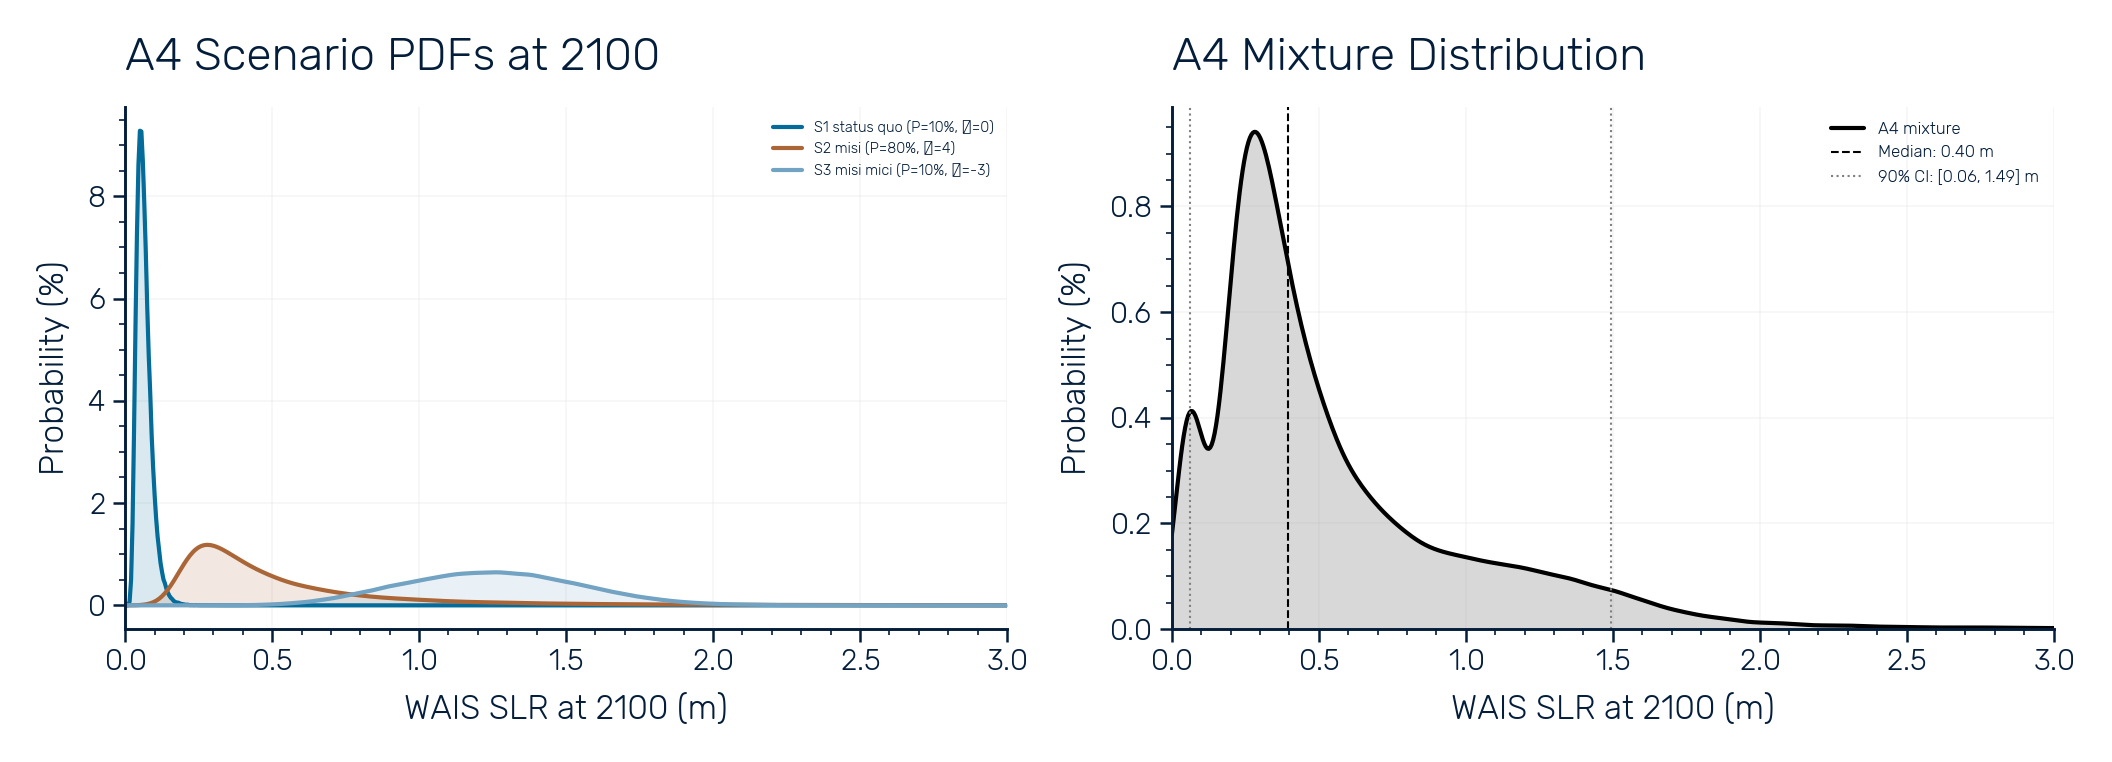

In [3]:
## WAIS scenario probabilities

scenario_colors = {'S1_status_quo': 'C0', 'S2_misi': 'C1', 'S3_misi_mici': 'C3'}
rng_scenarios = np.random.default_rng(42)
child_rngs = rng_scenarios.spawn(len(A4_SCENARIOS))

# Draw per-scenario endpoint samples
scenario_samples = {}
scenario_labels = {}
for (sname, params), s_rng in zip(A4_SCENARIOS.items(), child_rngs):
    weights = {s: (1.0 if s == sname else 0.0) for s in A4_SCENARIOS}
    scenario_samples[sname] = sample_a4_wais_endpoint(
        200000, s_rng, rheology_mode=RHEOLOGY_MODE,
        scenario_overrides={'weights': weights},
    )
    scenario_labels[sname] = (
        f'{sname.replace("_", " ")} '
        f'(P={params["P"]:.0%}, \u03b1={params["alpha"]:.0f})'
    )

# Mixture
mixture_m = sample_a4_wais_endpoint(200000, np.random.default_rng(99),
                                     rheology_mode=RHEOLOGY_MODE)

plot_a4_scenario_pdfs(
    scenario_samples, scenario_labels, scenario_colors,
    mixture_samples=mixture_m,
    component_name='WAIS', year=2100,
    xlim=(0, 3.0),
    save_path=f'{FIG_DIR}/component_wais_a4_scenarios.png',
)

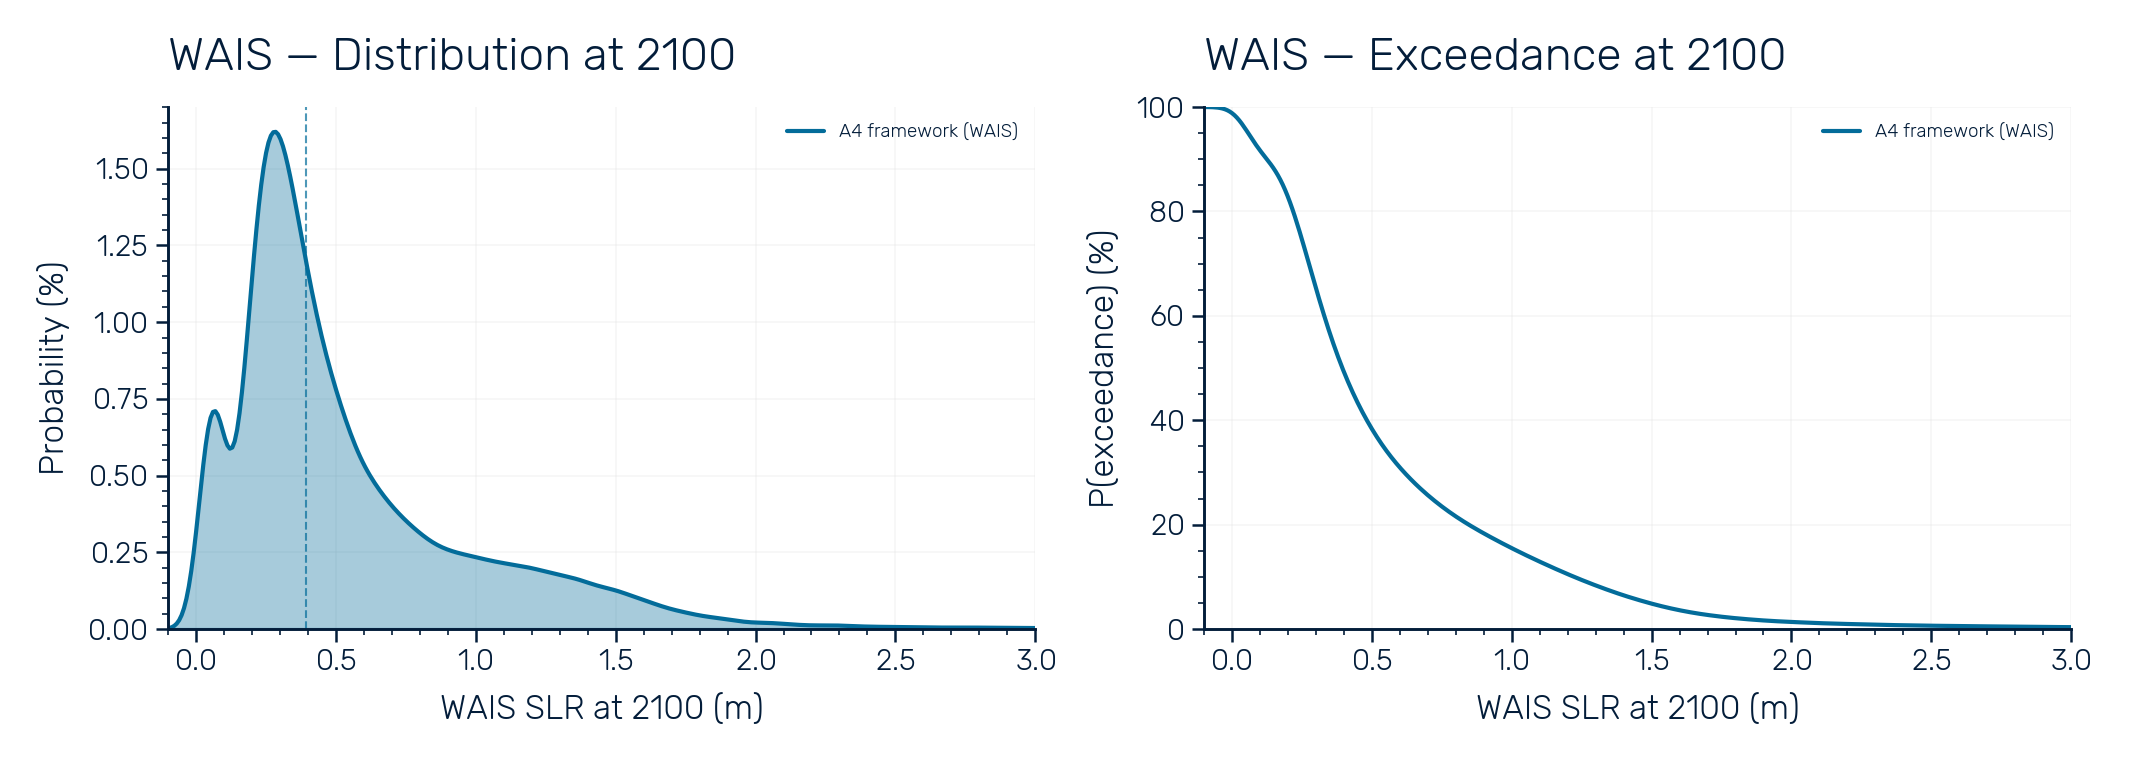

In [4]:
# A4 mixture: PDF + exceedance
plot_component_pdf_exceedance(
    [mixture_m], ['A4 framework (WAIS)'], [COMP_COLORS['WAIS']],
    'WAIS', year=2100, xlabel='WAIS SLR at 2100 (m)',
    xlim=(-0.1, 3.0),
    save_path=f'{FIG_DIR}/component_wais_pdf_exceedance.png',
)

In [5]:
# ── Validation: cross-check A4 quantiles against manuscript claims ──
N_VALID = 500_000
rng_valid = np.random.default_rng(42)

s2 = A4_SCENARIOS['S2_misi']
print(f'S2 bounds: {s2["low_mm"]}–{s2["high_mm"]} mm, α={s2["alpha"]:.0f}')

# Pre-correction S2 samples (no rheology)
s2_pre = _sample_log_skewnormal(N_VALID, s2['low_mm'], s2['high_mm'], s2['alpha'], rng_valid)
s2_pre_p5, s2_pre_med, s2_pre_p95 = np.percentile(s2_pre, [5, 50, 95])
print(f'\nS2 pre-correction:  median = {s2_pre_med:.0f} mm '
      f'[{s2_pre_p5:.0f}, {s2_pre_p95:.0f}]')

# Post-correction S2 samples (with rheology)
rheo_draws = rng_valid.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, N_VALID)
rheo_draws = np.maximum(rheo_draws, 1.0)
s2_post = s2_pre * rheo_draws
s2_post_p5, s2_post_med, s2_post_p95 = np.percentile(s2_post, [5, 50, 95])
print(f'S2 post-correction: median = {s2_post_med:.0f} mm '
      f'[{s2_post_p5:.0f}, {s2_post_p95:.0f}]')
print(f'Effective rheology factor on median: {s2_post_med / s2_pre_med:.2f}')

# Bamber et al. (2019) conditional-on-MISI median: ~250–300 mm
print(f'\nBamber conditional-on-MISI median: ~250–300 mm')
print(f'Our pre-correction S2 median:      ~{s2_pre_med:.0f} mm  '
      f'{"consistent" if 240 <= s2_pre_med <= 320 else "OUTSIDE expected range"}')

# Full A4 mixture quantiles
mix = sample_a4_wais_endpoint(N_VALID, np.random.default_rng(99),
                               rheology_mode=RHEOLOGY_MODE)
mix_p5, mix_med, mix_p95 = np.percentile(mix, [5, 50, 95])
print(f'\nFull A4 mixture at 2100: median = {mix_med*M_TO_MM:.0f} mm '
      f'[{mix_p5*M_TO_MM:.0f}, {mix_p95*M_TO_MM:.0f}] mm')
print(f'                      = {mix_med:.2f} m '
      f'[{mix_p5:.2f}, {mix_p95:.2f}] m')

S2 bounds: 150–1000 mm, α=4

S2 pre-correction:  median = 302 mm [150, 1002]
S2 post-correction: median = 387 mm [191, 1285]
Effective rheology factor on median: 1.28

Bamber conditional-on-MISI median: ~250–300 mm
Our pre-correction S2 median:      ~302 mm  consistent

Full A4 mixture at 2100: median = 396 mm [60, 1490] mm
                      = 0.40 m [0.06, 1.49] m


## 3. Diagnostics & Validation

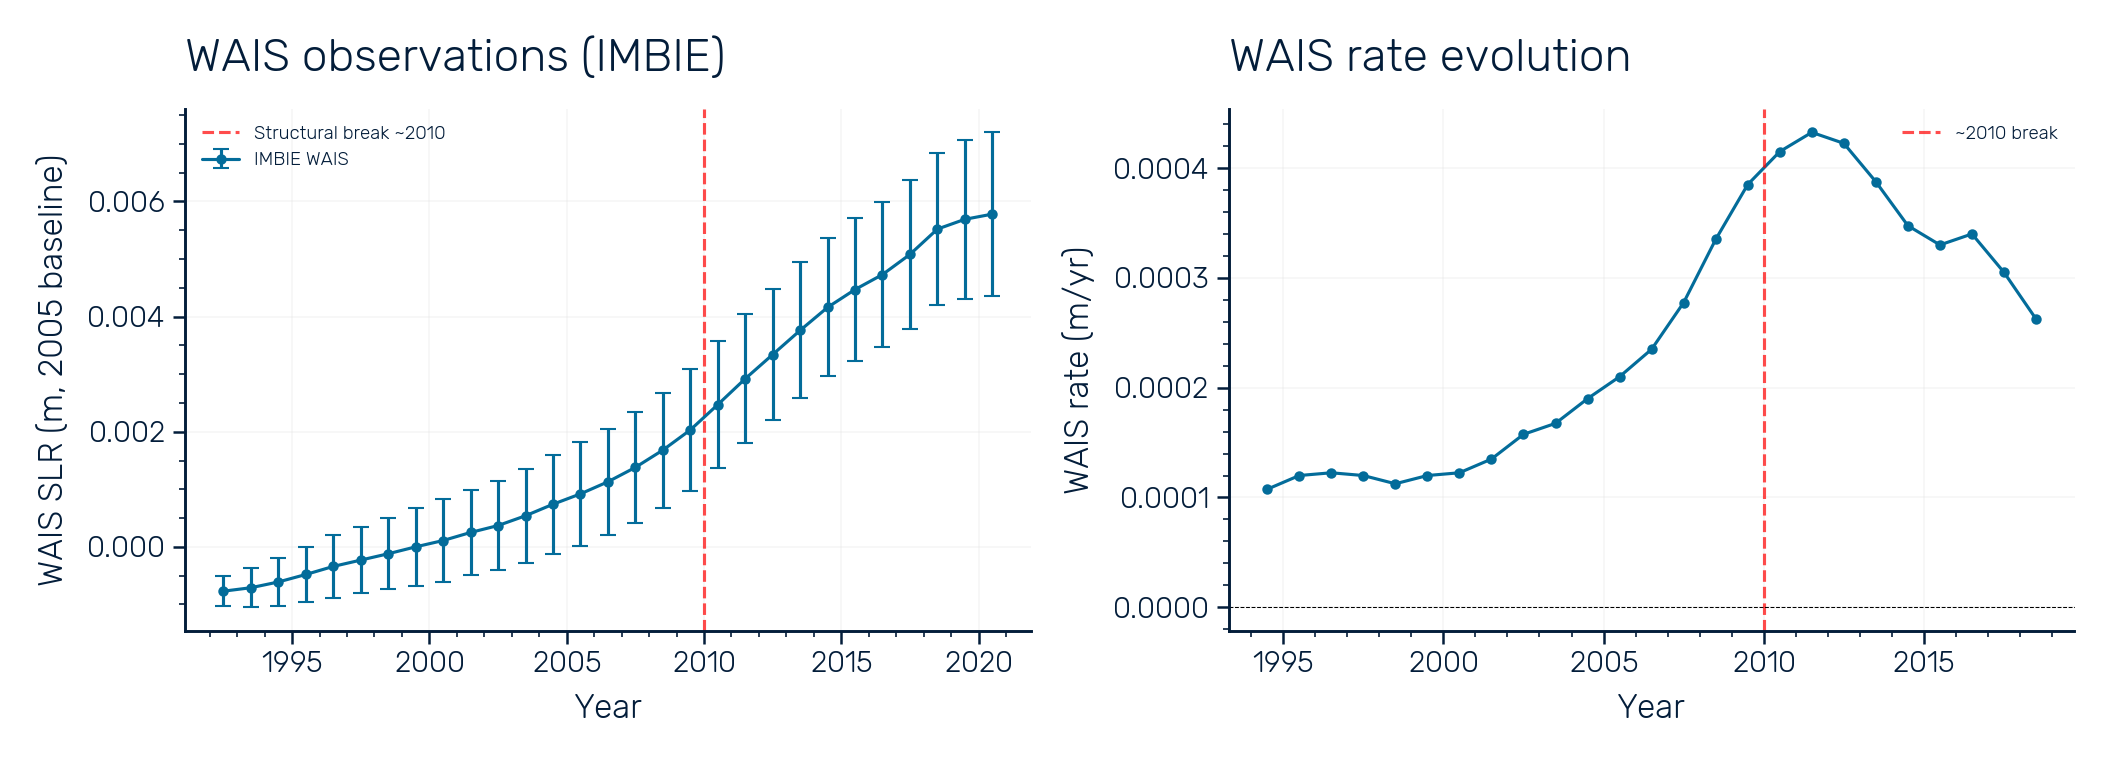

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IMBIE time series
ax = axes[0]
ax.errorbar(wais_year, wais_rebase, yerr=2*wais_sigma,
            fmt='o-', ms=4, color=COMP_COLORS['WAIS'], lw=1.5, label='IMBIE WAIS')
ax.axvline(WAIS_ONSET_YEAR, color='red', ls='--', lw=1.5, alpha=0.7,
           label=f'Structural break ~{WAIS_ONSET_YEAR:.0f}')
ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLR (m, 2000 baseline)')
ax.set_title('WAIS observations (IMBIE)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel B: Rate evolution
ax = axes[1]
from component_analysis import compute_component_rates
rates = compute_component_rates(wais_year, wais_rebase, window=2)
valid = np.isfinite(rates)
ax.plot(wais_year[valid], rates[valid], 'o-', ms=4, color=COMP_COLORS['WAIS'], lw=1.5)
ax.axvline(WAIS_ONSET_YEAR, color='red', ls='--', lw=1.5, alpha=0.7,
           label=f'~{WAIS_ONSET_YEAR:.0f} break')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('WAIS rate (m/yr)')
ax.set_title('WAIS rate evolution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_observations.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Projections

In [7]:
PROJ_YEARS = np.arange(1950, 2151, dtype=float)
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
rng_wais = np.random.default_rng(2026)

# ── Observational anchor ──
anchor_year = wais_year[-1]
anchor_value_mm = wais_rebase[-1] * M_TO_MM
anchor_sigma_mm = wais_sigma[-1] * M_TO_MM
print(f'Anchor: year={anchor_year:.0f}, '
      f'IMBIE={anchor_value_mm:.1f} \u00b1 {anchor_sigma_mm:.1f} mm (1\u03c3)')

# ── Draw coherent trajectories (returns meters) ──
wais_samples_m, wais_params = sample_a4_wais_trajectories(
    N_SAMPLES, rng_wais, PROJ_YEARS,
    rheology_mode=RHEOLOGY_MODE,
    anchor_year=anchor_year,
    anchor_value_mm=anchor_value_mm,
    anchor_sigma_mm=anchor_sigma_mm,
    obs_years=wais_year,
    obs_values_mm=wais_rebase * M_TO_MM,
    obs_sigmas_mm=wais_sigma * M_TO_MM,
)

# Build projection dict (same for all SSPs -- A4 is SSP-independent)
# Each SSP gets its own copy to prevent accidental cross-SSP mutation.
wais_proj = {}
for ssp in PROJ_SSPS:
    wais_proj[ssp] = {
        'samples': wais_samples_m.copy(),
        'median': np.median(wais_samples_m, axis=0),
        'p5': np.percentile(wais_samples_m, 5, axis=0),
        'p95': np.percentile(wais_samples_m, 95, axis=0),
        'p17': np.percentile(wais_samples_m, 17, axis=0),
        'p83': np.percentile(wais_samples_m, 83, axis=0),
    }

# Report
idx_anchor = np.argmin(np.abs(PROJ_YEARS - anchor_year))
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
med_anchor = np.median(wais_samples_m[:, idx_anchor])
sig_anchor = np.std(wais_samples_m[:, idx_anchor])
med = np.median(wais_samples_m[:, idx_2100])
p5 = np.percentile(wais_samples_m[:, idx_2100], 5)
p95 = np.percentile(wais_samples_m[:, idx_2100], 95)
print(f'WAIS at {anchor_year:.0f}: {med_anchor*M_TO_MM:.1f} \u00b1 {sig_anchor*M_TO_MM:.1f} mm '
      f'(IMBIE: {anchor_value_mm:.1f} \u00b1 {anchor_sigma_mm:.1f} mm)')
print(f'WAIS at 2100 (A4): {med:.2f} [{p5:.2f}, {p95:.2f}] m (SSP-independent)')

# Per-sample parameter summary
scenario_names = list(A4_SCENARIOS.keys())
for i, sn in enumerate(scenario_names):
    n_in = (wais_params['scenario_idx'] == i).sum()
    print(f'  {sn}: {n_in} samples ({n_in/N_SAMPLES:.0%})')
print(f'  Median beta: {np.median(wais_params["beta"]):.2f}')


Anchor: year=2020, IMBIE=5.8 ± 0.7 mm (1σ)


WAIS at 2020: 5.7 ± 0.7 mm (IMBIE: 5.8 ± 0.7 mm)
WAIS at 2100 (A4): 0.40 [0.06, 1.50] m (SSP-independent)
  S1_status_quo: 932 samples (9%)
  S2_misi: 7991 samples (80%)
  S3_misi_mici: 1077 samples (11%)
  Median beta: 2.25


In [8]:
# ── S1-only WAIS (no MISI): stable ice sheet scenario ──
# Override scenario weights to 100% S1, keeping everything else identical.
_saved_probs = {s: A4_SCENARIOS[s]['P'] for s in A4_SCENARIOS}
for s in A4_SCENARIOS:
    A4_SCENARIOS[s]['P'] = 1.0 if s == 'S1_status_quo' else 0.0

rng_s1 = np.random.default_rng(2026)
wais_s1_m, wais_s1_params = sample_a4_wais_trajectories(
    N_SAMPLES, rng_s1, PROJ_YEARS,
    rheology_mode=RHEOLOGY_MODE,
    anchor_year=anchor_year,
    anchor_value_mm=anchor_value_mm,
    anchor_sigma_mm=anchor_sigma_mm,
    obs_years=wais_year,
    obs_values_mm=wais_rebase * M_TO_MM,
    obs_sigmas_mm=wais_sigma * M_TO_MM,
)

# Restore original weights
for s in A4_SCENARIOS:
    A4_SCENARIOS[s]['P'] = _saved_probs[s]

# Report
med_s1 = np.median(wais_s1_m[:, idx_2100])
p5_s1 = np.percentile(wais_s1_m[:, idx_2100], 5)
p95_s1 = np.percentile(wais_s1_m[:, idx_2100], 95)
print(f'WAIS S1 (no MISI) at 2100: {med_s1:.3f} [{p5_s1:.3f}, {p95_s1:.3f}] m')
print(f'WAIS full mixture at 2100: {med:.3f} [{p5:.3f}, {p95:.3f}] m')

WAIS S1 (no MISI) at 2100: 0.060 [0.032, 0.112] m
WAIS full mixture at 2100: 0.404 [0.062, 1.501] m


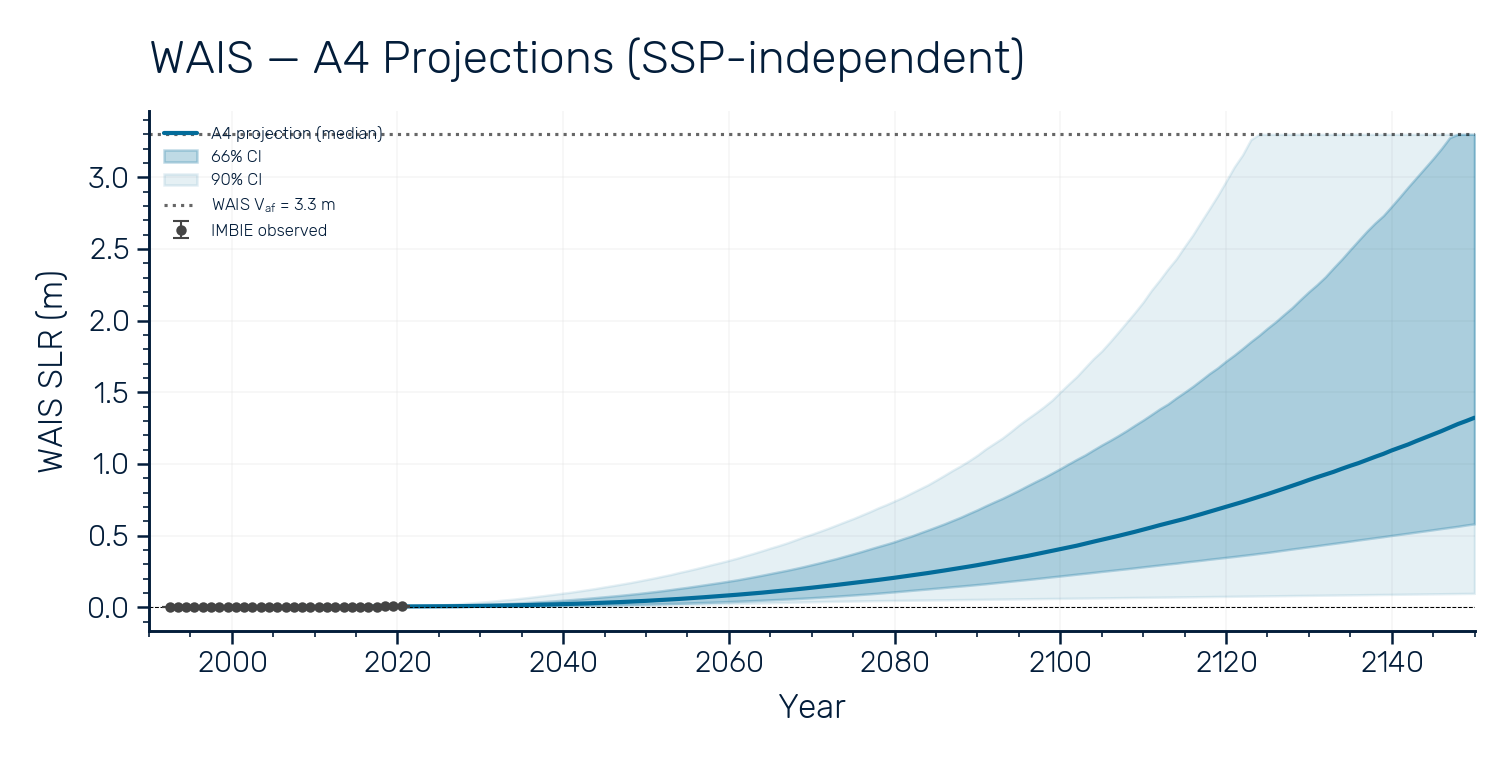

In [9]:
# WAIS has no temperature dependence — show obs + forward projection
# Total WAIS volume above flotation ~3.3 m SLE (Morlighem et al. 2020, BedMachine v3)
WAIS_VAF_M = 3.3

fig, ax = plt.subplots(figsize=(10, 5))

# Observations
ax.errorbar(wais_year, wais_rebase, yerr=2*wais_sigma,
            fmt='o', ms=4, color='#444444', lw=1, label='IMBIE observed', zorder=5)

# Projections (SSP-independent, show as single fan)
proj_mask = PROJ_YEARS >= BASELINE_YEAR
yr_plot = PROJ_YEARS[proj_mask]
p = wais_proj['SSP2-4.5']
ax.plot(yr_plot, p['median'][proj_mask], color=COMP_COLORS['WAIS'], lw=2,
        label='A4 projection (median)')
ax.fill_between(yr_plot, p['p17'][proj_mask],
                np.minimum(p['p83'][proj_mask], WAIS_VAF_M),
                color=COMP_COLORS['WAIS'], alpha=0.25, label='66% CI')
ax.fill_between(yr_plot, p['p5'][proj_mask],
                np.minimum(p['p95'][proj_mask], WAIS_VAF_M),
                color=COMP_COLORS['WAIS'], alpha=0.10, label='90% CI')

# Physical cap
ax.axhline(WAIS_VAF_M, color='k', ls=':', lw=1.5, alpha=0.6,
           label=f'WAIS $V_{{af}}$ = {WAIS_VAF_M} m')

ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLR (m)')
ax.set_title('WAIS \u2014 A4 Projections (SSP-independent)')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(1990, 2150)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_projection.png', dpi=150, bbox_inches='tight')
plt.show()

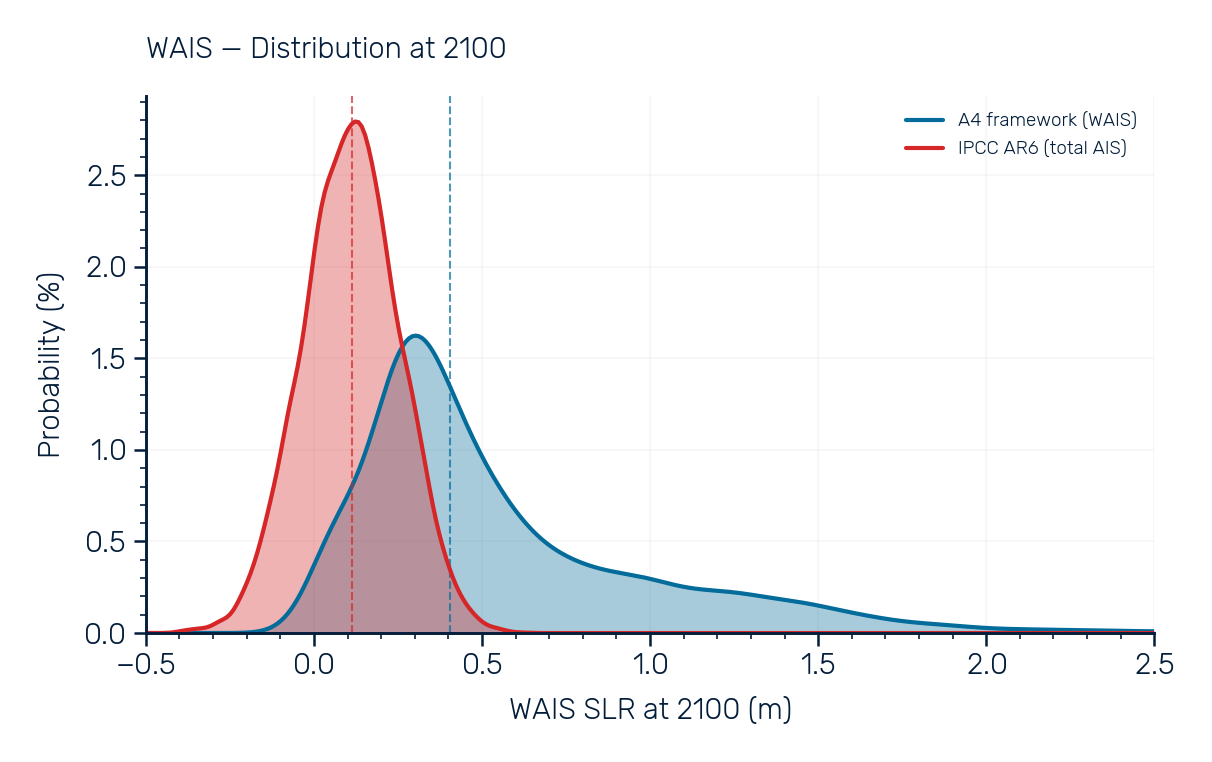

In [10]:
rng_hist = np.random.default_rng(99)
our_samples_m = wais_samples_m[:, idx_2100]

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
# NOTE: IPCC reports only total AIS (EAIS + Peninsula + WAIS), not WAIS alone.
# This comparison is intentionally asymmetric — our WAIS-only A4 framework vs
# IPCC total AIS — to show that A4 uncertainty for WAIS alone already exceeds
# the IPCC range for all of Antarctica.
ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', 'ssp245', 'AIS')
sample_sets = [our_samples_m]
labels = ['A4 framework (WAIS)']
colors = [COMP_COLORS['WAIS']]
if ipcc_data is not None:
    ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ex['years'] - 2100))
    ipcc_med = ex['q50'][yr_idx] / M_TO_MM
    ipcc_sig = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * Z_90) / M_TO_MM
    ipcc_samples_m = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples_m)
    labels.append('IPCC AR6 (total AIS)')
    colors.append('tab:red')

plot_component_histogram(sample_sets, labels, colors, 'WAIS', year=2100,
                          xlabel='WAIS SLR at 2100 (m)',
                          probability=True,xlim=(-0.5,2.5),
                          save_path=f'{FIG_DIR}/component_wais_histogram_2100.png')


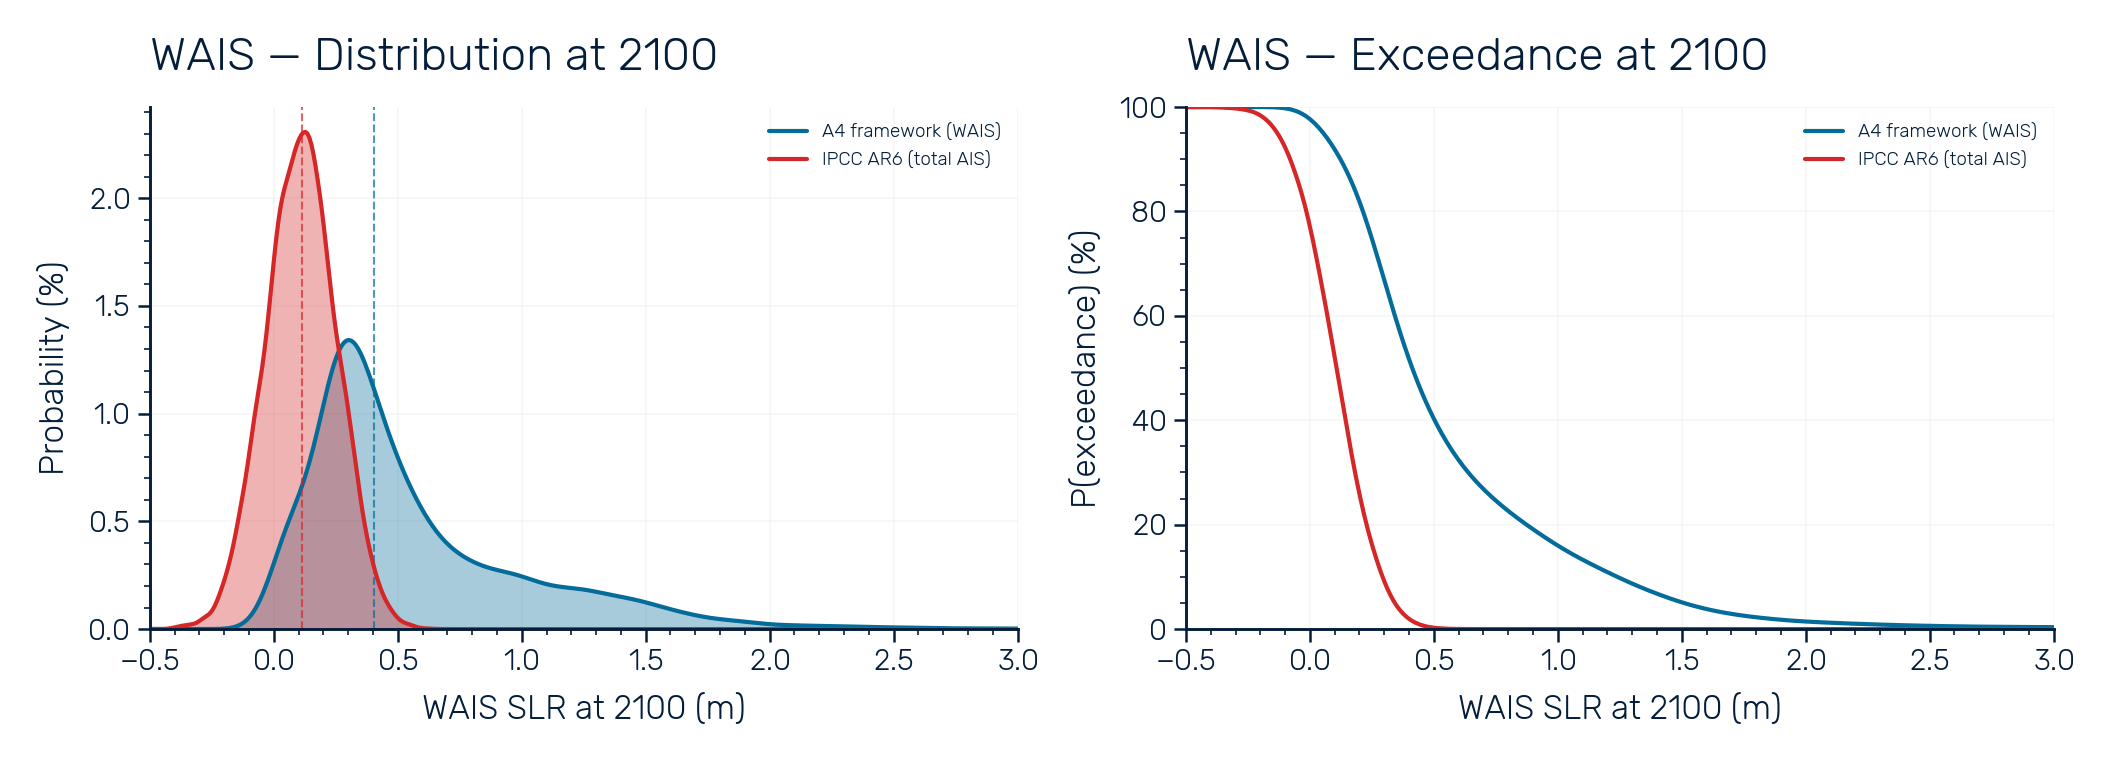

In [11]:
# A4 vs IPCC: PDF + exceedance
plot_component_pdf_exceedance(
    sample_sets, labels, colors,
    'WAIS', year=2100, xlabel='WAIS SLR at 2100 (m)',
    xlim=(-0.5, 3.0),
    save_path=f'{FIG_DIR}/component_wais_pdf_exceedance_ipcc.png',
)

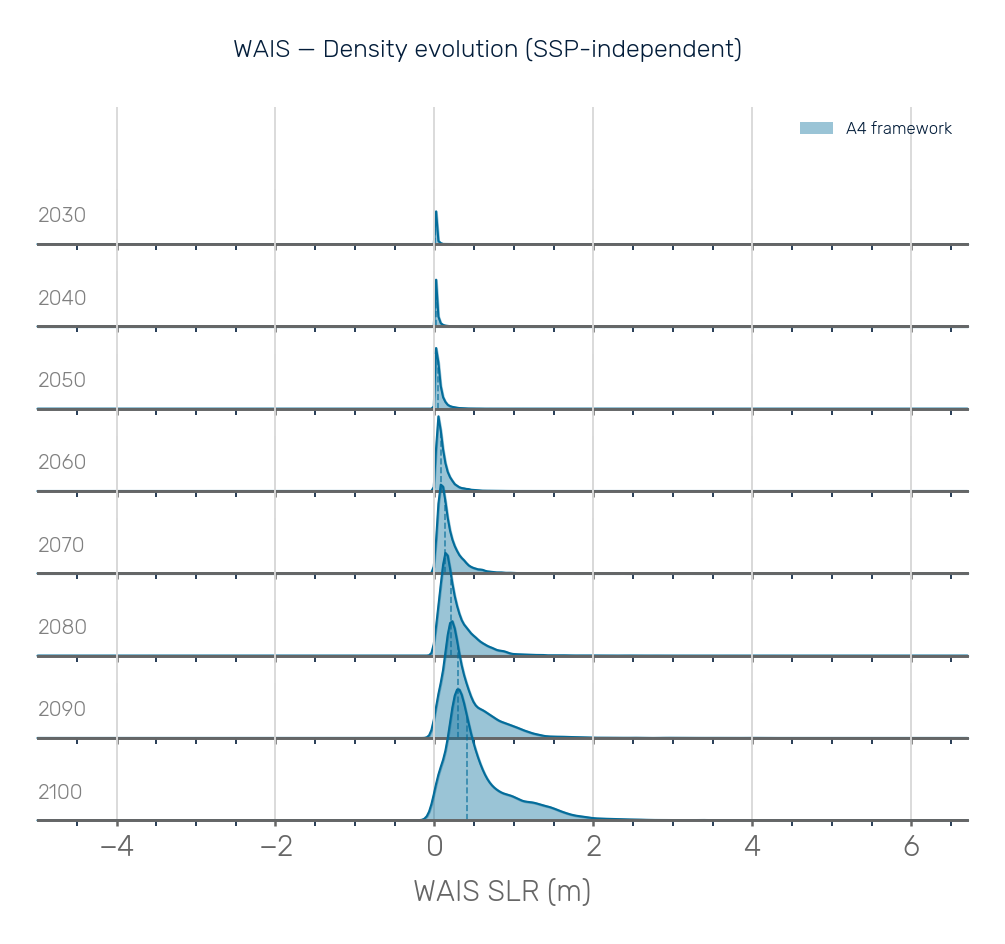

In [12]:
RIDGE_YEARS = list(range(2030, 2110, 10))
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    samples_by_year[yr] = {'A4 framework': wais_samples_m[:, idx_yr]}

plot_component_ridge(samples_by_year, 'WAIS', 'SSP-independent',
                      source_colors={'A4 framework': COMP_COLORS['WAIS']},
                      xlabel='WAIS SLR (m)',
                      save_path=f'{FIG_DIR}/component_wais_ridge.png')

## 5. IPCC Comparison

The IPCC AR6 AIS component combines EAIS + Peninsula + WAIS. Our A4 framework
produces wider uncertainty ranges than the IPCC medium-confidence AIS, reflecting
the deep uncertainty in marine ice sheet instability that process models
(ISMIP6) may underestimate.

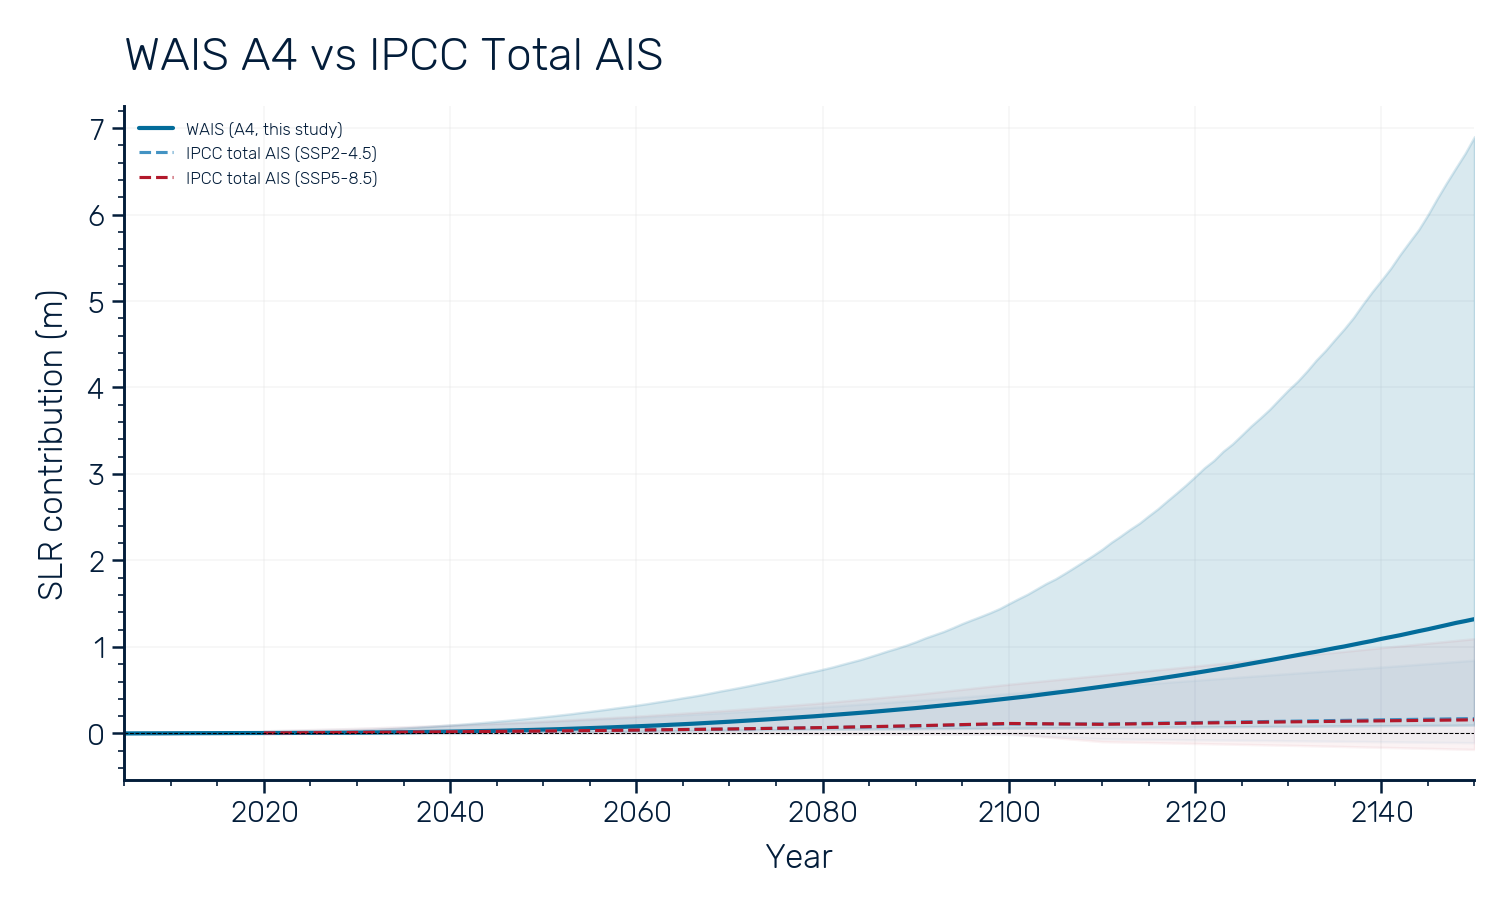

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
proj_mask = PROJ_YEARS >= 2005
yr_plot = PROJ_YEARS[proj_mask]

# Our WAIS
p = wais_proj['SSP2-4.5']
ax.plot(yr_plot, p['median'][proj_mask], color=COMP_COLORS['WAIS'], lw=2,
        label='WAIS (A4, this study)')
ax.fill_between(yr_plot, p['p5'][proj_mask], p['p95'][proj_mask],
                color=COMP_COLORS['WAIS'], alpha=0.15)

# IPCC total AIS
for ssp, ssp_code in [('SSP2-4.5', 'ssp245'), ('SSP5-8.5', 'ssp585')]:
    ipcc = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', ssp_code, 'AIS')
    if ipcc is not None:
        ex = ipcc_extract(ipcc)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(ex['years'], ex['q50'] / M_TO_MM, color=color, ls='--', lw=1.5,
                label=f'IPCC total AIS ({ssp})')
        ax.fill_between(ex['years'], ex['q05'] / M_TO_MM, ex['q95'] / M_TO_MM,
                        color=color, alpha=0.05)

ax.set_xlabel('Year')
ax.set_ylabel('SLR contribution (m)')
ax.set_title('WAIS A4 vs IPCC Total AIS')
ax.legend(fontsize=8)
ax.set_xlim(2005, 2150)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_ipcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Appendix: Sensitivity & Reviewer Q&A

### Scenario weight sensitivity
### Range sensitivity
### Rheology exponent sensitivity

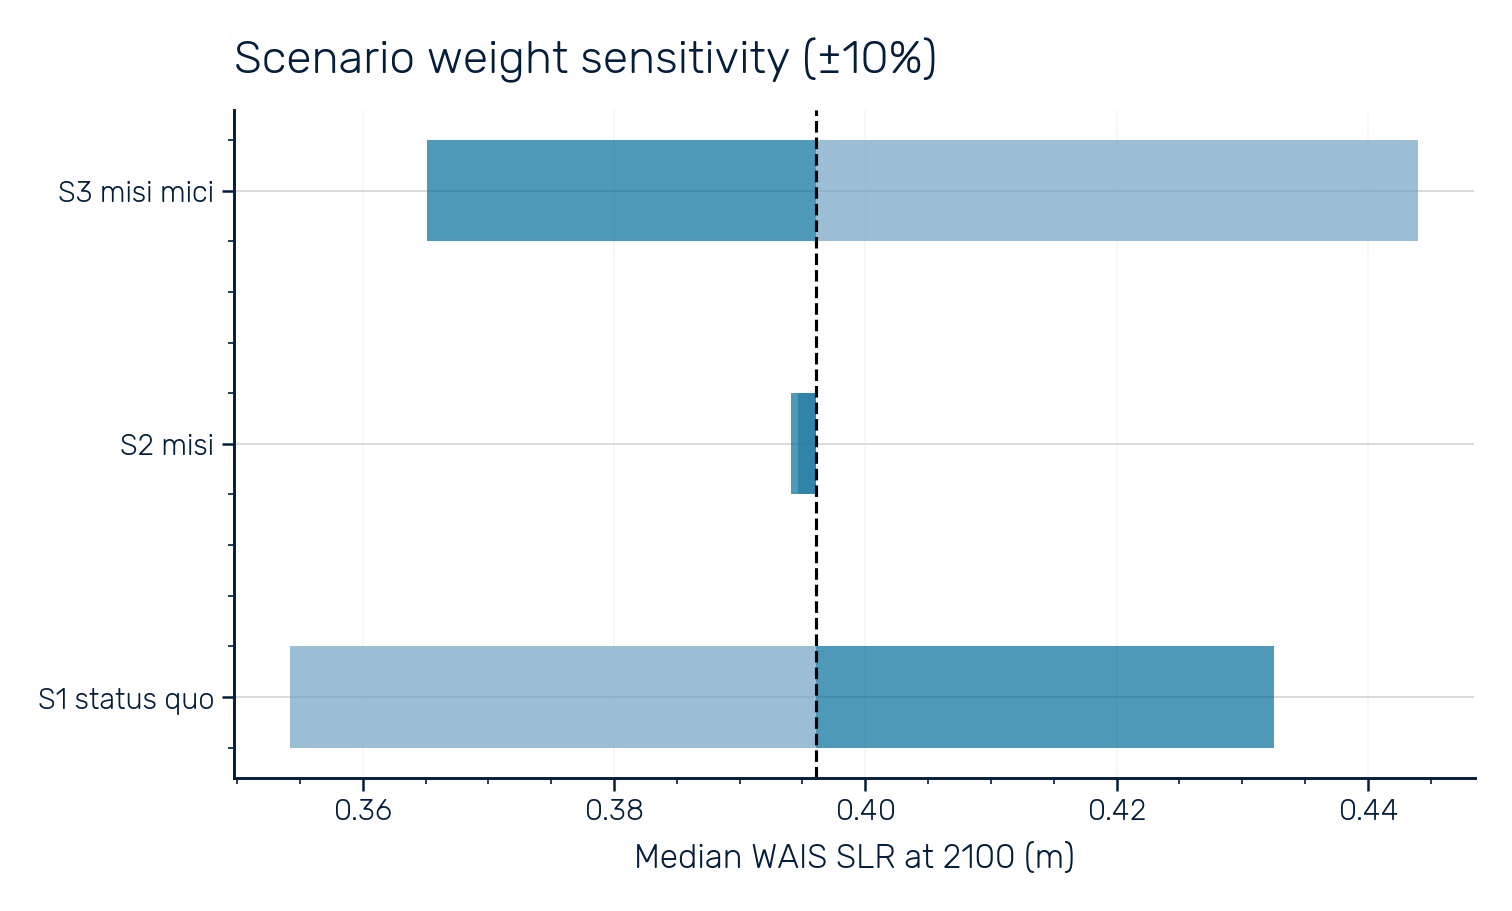

In [14]:
# ── Tornado diagram: perturb each scenario weight by ±0.10 ──
perturbation = 0.1
N_SENS = 100000

fig, ax = plt.subplots(figsize=(10, 6))

base_med = np.median(sample_a4_wais_endpoint(
    N_SENS, np.random.default_rng(1), rheology_mode=RHEOLOGY_MODE))

scenarios = list(A4_SCENARIOS.keys())
y_pos = np.arange(len(scenarios))
med_lo, med_hi = [], []

for i, sname in enumerate(scenarios):
    orig_p = A4_SCENARIOS[sname]['P']
    orig_remaining = 1.0 - orig_p

    for direction, storage in [('hi', med_hi), ('lo', med_lo)]:
        if direction == 'hi':
            new_p = min(orig_p + perturbation, 0.95)
            seed = 42 + i
        else:
            new_p = max(orig_p - perturbation, 0.01)
            seed = 142 + i

        remaining = 1.0 - new_p
        weights_mod = {}
        for s2 in scenarios:
            if s2 == sname:
                weights_mod[s2] = new_p
            else:
                weights_mod[s2] = A4_SCENARIOS[s2]['P'] * remaining / orig_remaining

        samples_mod = sample_a4_wais_endpoint(
            N_SENS, np.random.default_rng(seed),
            rheology_mode=RHEOLOGY_MODE,
            scenario_overrides={'weights': weights_mod},
        )
        storage.append(np.median(samples_mod))

# Tornado
for i, sname in enumerate(scenarios):
    ax.barh(y_pos[i], med_hi[i] - base_med, left=base_med, height=0.4,
            color='C3', alpha=0.7)
    ax.barh(y_pos[i], med_lo[i] - base_med, left=base_med, height=0.4,
            color='C0', alpha=0.7)

ax.axvline(base_med, color='k', ls='--', lw=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace('_', ' ') for s in scenarios])
ax.set_xlabel('Median WAIS SLR at 2100 (m)')
ax.set_title(f'Scenario weight sensitivity (\u00b1{perturbation:.0%})')
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_tornado.png', dpi=150, bbox_inches='tight')
plt.show()

### Physically motivated weight alternatives

The tornado diagram above perturbs each scenario weight independently by
$\pm$10 percentage points. Here we test complete, physically motivated
weight combinations that represent distinct interpretive stances on WAIS
dynamics. For each combination, we report the 5th, 50th, and 95th
percentiles of the A4 mixture distribution at 2100 (Mode B rheology).

In [15]:
# ── Physically motivated weight alternatives ──
N_WEIGHT_SENS = 100_000

weight_combos = {
    'Baseline (10/80/10)':          {'S1_status_quo': 0.10, 'S2_misi': 0.80, 'S3_misi_mici': 0.10},
    'Conservative (20/70/10)':      {'S1_status_quo': 0.20, 'S2_misi': 0.70, 'S3_misi_mici': 0.10},
    'Skeptical of MISI (30/60/10)': {'S1_status_quo': 0.30, 'S2_misi': 0.60, 'S3_misi_mici': 0.10},
    'Higher MICI (10/70/20)':       {'S1_status_quo': 0.10, 'S2_misi': 0.70, 'S3_misi_mici': 0.20},
    'Equal tails (15/70/15)':       {'S1_status_quo': 0.15, 'S2_misi': 0.70, 'S3_misi_mici': 0.15},
}

print(f'{"Weight combination":<30s}  {"p5 (m)":>8s}  {"p50 (m)":>8s}  {"p95 (m)":>8s}')
print('-' * 62)

for label, weights in weight_combos.items():
    assert abs(sum(weights.values()) - 1.0) < 1e-10, f'Weights do not sum to 1: {weights}'
    samples = sample_a4_wais_endpoint(
        N_WEIGHT_SENS, np.random.default_rng(314),
        rheology_mode='B',
        scenario_overrides={'weights': weights},
    )
    p5, p50, p95 = np.percentile(samples, [5, 50, 95])
    print(f'{label:<30s}  {p5:8.3f}  {p50:8.3f}  {p95:8.3f}')


Weight combination                p5 (m)   p50 (m)   p95 (m)
--------------------------------------------------------------
Baseline (10/80/10)                0.060     0.396     1.498
Conservative (20/70/10)            0.046     0.359     1.472
Skeptical of MISI (30/60/10)       0.041     0.314     1.447
Higher MICI (10/70/20)             0.060     0.443     1.577
Equal tails (15/70/15)             0.051     0.397     1.534


In [16]:
# ── Range sensitivity: ±20% on (low, high) bounds ──
N_SENS = 100000

print('Range sensitivity (\u00b120% on bounds):')
for factor_label, range_factor in [('-20%', 0.8), ('Base', 1.0), ('+20%', 1.2)]:
    overrides = {}
    for sname, s in A4_SCENARIOS.items():
        overrides[sname] = {'low_mm': s['low_mm'] * range_factor,
                            'high_mm': s['high_mm'] * range_factor}
    samples = sample_a4_wais_endpoint(
        N_SENS, np.random.default_rng(77), rheology_mode=RHEOLOGY_MODE,
        scenario_overrides=overrides,
    )
    p5, med, p95 = np.percentile(samples, [5, 50, 95])
    print(f'  {factor_label}: median={med:.2f} [{p5:.2f}, {p95:.2f}] m')

# ── Rheology exponent sensitivity ──
print('\nRheology exponent sensitivity:')
for n_exp in [3.5, 4.0, 4.5]:
    rheo_med = 1 + RHEOLOGY_SENSITIVITY * (n_exp - N_REF)
    rng_rh = np.random.default_rng(88)
    scenarios = list(A4_SCENARIOS.keys())
    probs = [A4_SCENARIOS[s]['P'] for s in scenarios]
    samples_rh = np.zeros(N_SENS)
    scenario_idx = rng_rh.choice(len(scenarios), size=N_SENS, p=probs)
    child_rngs = rng_rh.spawn(len(scenarios))
    for k, sname in enumerate(scenarios):
        mask = scenario_idx == k
        n_s = mask.sum()
        if n_s == 0:
            continue
        s = A4_SCENARIOS[sname]
        crng = child_rngs[k]
        base_s = _sample_log_skewnormal(
            n_s, s['low_mm'], s['high_mm'], s['alpha'], crng,
        )
        rheo = crng.normal(rheo_med, RHEOLOGY_FACTOR_SIGMA, n_s)
        rheo = np.maximum(rheo, 1.0)
        base_s *= rheo
        samples_rh[mask] = base_s
    samples_rh /= M_TO_MM  # mm -> m
    p5, med, p95 = np.percentile(samples_rh, [5, 50, 95])
    print(f'  n={n_exp}: rheology factor={rheo_med:.2f}, '
          f'median={med:.2f} [{p5:.2f}, {p95:.2f}] m')

# ── Skewness sensitivity ──
print('\nSkewness (alpha) sensitivity for S2:')
for alpha_test in [0, 2, 4, 6]:
    overrides = {'S2_misi': {'alpha': alpha_test}}
    samples = sample_a4_wais_endpoint(
        N_SENS, np.random.default_rng(55), rheology_mode=RHEOLOGY_MODE,
        scenario_overrides=overrides,
    )
    p5, med, p95 = np.percentile(samples, [5, 50, 95])
    print(f'  alpha={alpha_test}: median={med:.2f} [{p5:.2f}, {p95:.2f}] m')

Range sensitivity (±20% on bounds):
  -20%: median=0.32 [0.05, 1.20] m
  Base: median=0.39 [0.06, 1.50] m
  +20%: median=0.47 [0.07, 1.79] m

Rheology exponent sensitivity:
  n=3.5: rheology factor=1.14, median=0.35 [0.05, 1.29] m
  n=4.0: rheology factor=1.28, median=0.39 [0.06, 1.45] m
  n=4.5: rheology factor=1.42, median=0.43 [0.06, 1.61] m

Skewness (alpha) sensitivity for S2:
  alpha=0: median=0.51 [0.06, 1.47] m
  alpha=2: median=0.44 [0.06, 1.49] m
  alpha=4: median=0.40 [0.06, 1.50] m
  alpha=6: median=0.38 [0.06, 1.50] m


In [17]:
# ══════════════════════════════════════════════════════════════════
# §6  Export results to HDF5
# ══════════════════════════════════════════════════════════════════
from component_io import save_wais

# WAIS is SSP-independent: all SSPs share identical samples.
# Store full samples only for the first SSP; omit from the rest
# to avoid 4x redundant writes to HDF5.
wais_proj_lean = {}
for i, ssp in enumerate(PROJ_SSPS):
    proj_i = dict(wais_proj[ssp])  # shallow copy of the dict
    if i > 0:
        proj_i.pop('samples', None)  # omit redundant samples
    wais_proj_lean[ssp] = proj_i

save_wais(
    a4_scenarios=A4_SCENARIOS,
    obs_years=wais_year,
    obs_H=wais_rebase,
    obs_sigma=wais_sigma,
    wais_proj=wais_proj_lean,
    rheology_factor_median=RHEOLOGY_FACTOR_MEDIAN,
    rheology_factor_sigma=RHEOLOGY_FACTOR_SIGMA,
    rheology_mode=RHEOLOGY_MODE,
    wais_onset_year=WAIS_ONSET_YEAR,
)


# ── Save S1-only (stable WAIS) samples separately ──
# Save both the full 10k ensemble and a 2k downsampled version.
# The 2k version is used by component_forecast.ipynb for the
# stable-WAIS blended forecast, keeping sample sizes consistent
# across components.  Downsampling is done here (at the source)
# so the resampling logic lives with the WAIS code.
import h5py as _h5
from component_io import DEFAULT_H5_PATH
from slr_forecast.config import N_SAMPLES as N_SAMPLES_DEFAULT  # 2000

_rng_ds = np.random.default_rng(2026)

# Downsample to N_SAMPLES_DEFAULT if WAIS was generated with more samples.
# When N_SAMPLES == N_SAMPLES_DEFAULT (the current default), this is a no-op.
if wais_samples_m.shape[0] > N_SAMPLES_DEFAULT:
    _idx_full_ds = _rng_ds.choice(wais_samples_m.shape[0], size=N_SAMPLES_DEFAULT, replace=False)
    _idx_s1_ds = _rng_ds.choice(wais_s1_m.shape[0], size=N_SAMPLES_DEFAULT, replace=False)
    wais_full_2k = wais_samples_m[_idx_full_ds]
    wais_s1_2k = wais_s1_m[_idx_s1_ds]
else:
    wais_full_2k = wais_samples_m
    wais_s1_2k = wais_s1_m

with _h5.File(DEFAULT_H5_PATH, 'a') as hf:
    # ── S1 full (10k) ──
    if 'wais_s1' in hf:
        del hf['wais_s1']
    sg = hf.create_group('wais_s1')
    sg.attrs['description'] = (
        'S1 (no-MISI) WAIS projections: 100% weight on S1_status_quo scenario. '
        'Linear ramp, no marine ice-sheet instability.'
    )
    sg.attrs['scenario'] = 'S1_status_quo'
    sg.attrs['rheology_mode'] = RHEOLOGY_MODE
    sg.create_dataset('years', data=PROJ_YEARS)
    sg.create_dataset('samples', data=wais_s1_m, compression='gzip')
    sg.create_dataset('median', data=np.median(wais_s1_m, axis=0))
    sg.create_dataset('p5', data=np.percentile(wais_s1_m, 5, axis=0))
    sg.create_dataset('p95', data=np.percentile(wais_s1_m, 95, axis=0))

    # ── Downsampled (2k) versions for component_forecast ──
    if 'wais_2k' in hf:
        del hf['wais_2k']
    dg = hf.create_group('wais_2k')
    dg.attrs['description'] = (
        f'WAIS samples for component_forecast.ipynb ({N_SAMPLES_DEFAULT} samples). '
        f'Downsampled from {N_SAMPLES} if overridden, otherwise identical to full. '
        'Full mixture and S1-only.'
    )
    dg.attrs['n_full'] = N_SAMPLES
    dg.attrs['n_downsampled'] = N_SAMPLES_DEFAULT
    dg.create_dataset('years', data=PROJ_YEARS)
    dg.create_dataset('full_samples', data=wais_full_2k, compression='gzip')
    dg.create_dataset('s1_samples', data=wais_s1_2k, compression='gzip')

print(f'Saved wais_s1 samples: {wais_s1_m.shape}')
print(f'Saved wais_2k: full {wais_full_2k.shape}, s1 {wais_s1_2k.shape}')


Saved wais → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (449012 KB total)


Saved wais_s1 samples: (10000, 201)
Saved wais_2k: full (2000, 201), s1 (2000, 201)


---

## References

| Citation | Full reference | DOI |
|----------|--------------|-----|
| Bamber et al. (2019) | Bamber, Oppenheimer, Kopp, Aspinall & Cooke. Ice sheet contributions to future sea-level rise from structured expert judgment. *PNAS* 116, 11195--11200. | [10.1073/pnas.1817205116](https://doi.org/10.1073/pnas.1817205116) |
| Bassis & Walker (2012) | Bassis & Walker. Upper and lower limits on the stability of calving glaciers from the yield strength envelope of ice. *Proc. R. Soc. A* 468, 913--931. | [10.1098/rspa.2011.0422](https://doi.org/10.1098/rspa.2011.0422) |
| Bons et al. (2018) | Bons et al. Greenland Ice Sheet: Higher nonlinearity of ice flow significantly reduces estimated basal motion. *GRL* 45, 6542--6548. | [10.1029/2018GL078356](https://doi.org/10.1029/2018GL078356) |
| Clerc et al. (2019) | Clerc, Minchew & Behn. Marine ice cliff instability mitigated by slow removal of ice shelves. *GRL* 46, 12108--12116. | [10.1029/2019GL084183](https://doi.org/10.1029/2019GL084183) |
| DeConto & Pollard (2016) | DeConto & Pollard. Contribution of Antarctica to past and future sea-level rise. *Nature* 531, 591--597. | [10.1038/nature17145](https://doi.org/10.1038/nature17145) |
| DeConto et al. (2021) | DeConto et al. The Paris Climate Agreement and future sea-level rise from Antarctica. *Nature* 593, 83--89. | [10.1038/s41586-021-03427-0](https://doi.org/10.1038/s41586-021-03427-0) |
| Dow et al. (2022) | Dow et al. Antarctic basal environment shaped by high-pressure flow through a subglacial river system. *Nature Geoscience* 15, 892--898. | [10.1038/s41561-022-01059-1](https://doi.org/10.1038/s41561-022-01059-1) |
| Edwards et al. (2019) | Edwards et al. Revisiting Antarctic ice loss due to marine ice-cliff instability. *Nature* 566, 58--64. | [10.1038/s41586-019-0901-4](https://doi.org/10.1038/s41586-019-0901-4) |
| Fan et al. (2025) | Fan et al. Flow laws for ice constrained by 70 years of laboratory experiments. *Nature Geoscience* 18, 296--304. | [10.1038/s41561-025-01661-z](https://doi.org/10.1038/s41561-025-01661-z) |
| Fox-Kemper et al. (2021) | Fox-Kemper et al. Ocean, cryosphere and sea level change. In *IPCC AR6 WGI*, Ch. 9. | [10.1017/9781009157896.011](https://doi.org/10.1017/9781009157896.011) |
| Getraer & Morlighem (2025) | Getraer & Morlighem. Increasing the Glen-Nye power-law exponent accelerates ice-loss projections for the Amundsen Sea Embayment. *GRL* 52, e2024GL112516. | [10.1029/2024GL112516](https://doi.org/10.1029/2024GL112516) |
| Goldberg et al. (2026) | Goldberg, Morlighem & Gourmelen. Recent observations of Thwaites Glacier, West Antarctica are consistent with high rates of loss in next 50 years. *GRL* 53, e2025GL118823. | [10.1029/2025GL118823](https://doi.org/10.1029/2025GL118823) |
| Graham et al. (2022) | Graham et al. Rapid retreat of Thwaites Glacier in the pre-satellite era. *Nature Geoscience* 15, 706--713. | [10.1038/s41561-022-01019-9](https://doi.org/10.1038/s41561-022-01019-9) |
| Gudmundsson et al. (2012) | Gudmundsson et al. The stability of grounding lines on retrograde slopes. *The Cryosphere* 6, 1497--1505. | [10.5194/tc-6-1497-2012](https://doi.org/10.5194/tc-6-1497-2012) |
| Haseloff & Sergienko (2018) | Haseloff & Sergienko. The effect of buttressing on grounding line dynamics. *J. Glaciol.* 64, 417--431. | [10.1017/jog.2018.30](https://doi.org/10.1017/jog.2018.30) |
| Joughin et al. (2014) | Joughin, Smith & Medley. Marine ice sheet collapse potentially under way for the Thwaites Glacier Basin. *Science* 344, 735--738. | [10.1126/science.1249055](https://doi.org/10.1126/science.1249055) |
| Joughin et al. (2021) | Joughin, Shapero, Dutrieux & Smith. Ocean-induced melt volume directly paces ice loss from Pine Island Glacier. *Science Advances* 7, eabi5738. | [10.1126/sciadv.abi5738](https://doi.org/10.1126/sciadv.abi5738) |
| Jourdain et al. (2022) | Jourdain et al. Ice shelf basal melt rates in the Amundsen Sea at the end of the 21st century. *GRL* 49, e2022GL100629. | [10.1029/2022GL100629](https://doi.org/10.1029/2022GL100629) |
| Martin et al. (2026) | Martin, Kachuck, Trevers, Millstein, Cornford & Minchew. Rates of sea-level rise are highly sensitive to ice viscosity parameters in model benchmarks. *AGU Advances* 7(2). | [10.1029/2025AV001946](https://doi.org/10.1029/2025AV001946) |
| Millstein et al. (2022) | Millstein, Minchew & Pegler. Ice viscosity is more sensitive to stress than commonly assumed. *Commun. Earth Environ.* 3, 57. | [10.1038/s43247-022-00385-x](https://doi.org/10.1038/s43247-022-00385-x) |
| Morlighem et al. (2020) | Morlighem et al. Deep glacial troughs and stabilizing ridges unveiled beneath the margins of the Antarctic ice sheet. *Nature Geoscience* 13, 132--137. | [10.1038/s41561-019-0510-8](https://doi.org/10.1038/s41561-019-0510-8) |
| Morlighem et al. (2024) | Morlighem et al. The West Antarctic ice sheet may not be vulnerable to marine ice cliff instability during the 21st century. *Science Advances* 10, eado7794. | [10.1126/sciadv.ado7794](https://doi.org/10.1126/sciadv.ado7794) |
| Naughten et al. (2023) | Naughten, Holland & De Rydt. Unavoidable future increase in West Antarctic ice-shelf melting over the twenty-first century. *Nature Climate Change* 13, 1222--1228. | [10.1038/s41558-023-01818-x](https://doi.org/10.1038/s41558-023-01818-x) |
| Otosaka et al. (2023) | Otosaka et al. Mass balance of the Greenland and Antarctic ice sheets from 1992 to 2020. *ESSD* 15, 1597--1616. | [10.5194/essd-15-1597-2023](https://doi.org/10.5194/essd-15-1597-2023) |
| Pegler (2018) | Pegler. Marine ice sheet dynamics: the impacts of ice-shelf buttressing. *J. Fluid Mech.* 857, 605--647. | [10.1017/jfm.2018.741](https://doi.org/10.1017/jfm.2018.741) |
| Pfeffer et al. (2008) | Pfeffer, Harper & O'Neel. Kinematic constraints on glacier contributions to 21st-century sea-level rise. *Science* 321, 1340--1343. | [10.1126/science.1159099](https://doi.org/10.1126/science.1159099) |
| Ranganathan & Minchew (2024) | Ranganathan & Minchew. A modified viscous flow law for natural glacier ice: Scaling from laboratories to ice sheets. *PNAS* 121(23). | [10.1073/pnas.2309788121](https://doi.org/10.1073/pnas.2309788121) |
| Rignot et al. (2026) | Rignot et al. Thirty years of glacier grounding line retreat in Antarctica. *PNAS* 123(10), e2524380123. | [10.1073/pnas.2524380123](https://doi.org/10.1073/pnas.2524380123) |
| Robel et al. (2019) | Robel, Seroussi & Roe. Marine ice sheet instability amplifies and skews uncertainty in projections of future sea-level rise. *PNAS* 116, 14887--14892. | [10.1073/pnas.1904822116](https://doi.org/10.1073/pnas.1904822116) |
| Schlemm et al. (2022) | Schlemm, Feldmann, Winkelmann & Levermann. Stabilizing effect of m\u00e9lange buttressing on the marine ice-cliff instability of the West Antarctic Ice Sheet. *The Cryosphere* 16, 1979--1996. | [10.5194/tc-16-1979-2022](https://doi.org/10.5194/tc-16-1979-2022) |
| Schoof (2007) | Schoof. Ice sheet grounding line dynamics: Steady states, stability, and hysteresis. *JGR Earth Surface* 112, F03S28. | [10.1029/2006JF000664](https://doi.org/10.1029/2006JF000664) |
| Schoof (2012) | Schoof. Marine ice sheet stability. *J. Fluid Mech.* 698, 62--72. | [10.1017/jfm.2012.43](https://doi.org/10.1017/jfm.2012.43) |
| Seroussi et al. (2020) | Seroussi et al. ISMIP6 Antarctica: a multi-model ensemble of the Antarctic ice sheet evolution over the 21st century. *The Cryosphere* 14, 3033--3070. | [10.5194/tc-14-3033-2020](https://doi.org/10.5194/tc-14-3033-2020) |
| van den Akker et al. (2025) | van den Akker et al. Present-day mass loss rates are a precursor for West Antarctic Ice Sheet collapse. *The Cryosphere* 19, 283--301. | [10.5194/tc-19-283-2025](https://doi.org/10.5194/tc-19-283-2025) |
